<h1 style="color:#56B4E9;">Cardiac Patient Monitoring — Heart Disease Classification Module</h1>

<h2 style="color:#0072B2;">Machine Learning Analysis of Heart Disease Presence</h2>

### Project Question

Can patient clinical measurements and test-related features be used to classify the presence of heart disease while maintaining a reliable and leakage-free machine-learning workflow?

### Project Scope

This project is limited to the techniques covered during **Weeks 1–4** of the AI & Machine Learning training.

The analysis will progress from data inspection and exploratory analysis to supervised learning, reliable evaluation, feature engineering, and a reproducible Scikit-learn pipeline.

<span style="color:#009E73;"><b>Main objective:</b></span>  
The goal is not only to obtain a strong classification score, but to make every cleaning, preprocessing, modeling, and evaluation decision based on observable evidence from the data.

<h2 style="color:#0072B2;">1. Dataset Source and Target Definition</h2>

### Dataset Source

This project uses the **processed Cleveland database** from the Heart Disease Databases collection.

The accompanying `heart-disease.names` documentation states that the original databases contain **76 attributes**, while previous machine-learning experiments used a subset of **14 attributes**.

The processed Cleveland dataset contains these 14 variables directly:

- **13 input features**
- **1 target variable (`num`)**

The documentation reports **303 patient records** for the Cleveland database.

Because `processed.cleveland.data` does not contain a header row, the column names and their order are taken directly from the accompanying dataset documentation rather than inferred from the values.

### Target Definition

The documentation describes `num` as the heart-disease diagnosis variable and states that it ranges from **0 to 4**.

Previous experiments with the Cleveland database simplified this into a binary classification problem:

- `0` → absence of heart disease
- `1, 2, 3, 4` → presence of heart disease

The original target will remain unchanged during the initial data audit so its structure can be verified before creating the binary classification target.


<h3 style="color:#009E73;">Dataset Dictionary</h3>

The following definitions are based on the accompanying `heart-disease.names` documentation.

| Feature | Description | Coding / Unit | Modeling Role |
|---|---|---|---|
| `age` | Age | years | Numeric |
| `sex` | Sex | 0 = female, 1 = male | Binary categorical |
| `cp` | Chest pain type | 1 = typical angina, 2 = atypical angina, 3 = non-anginal pain, 4 = asymptomatic | Categorical |
| `trestbps` | Resting blood pressure on admission | mm Hg | Numeric |
| `chol` | Serum cholesterol | mg/dl | Numeric |
| `fbs` | Fasting blood sugar > 120 mg/dl | 0 = false, 1 = true | Binary categorical |
| `restecg` | Resting electrocardiographic result | 0 = normal, 1 = ST-T abnormality, 2 = probable/definite LV hypertrophy | Categorical |
| `thalach` | Maximum heart rate achieved | numeric measurement | Numeric |
| `exang` | Exercise-induced angina | 0 = no, 1 = yes | Binary categorical |
| `oldpeak` | ST depression induced by exercise relative to rest | numeric measurement | Numeric |
| `slope` | Slope of peak exercise ST segment | 1 = upsloping, 2 = flat, 3 = downsloping | Categorical |
| `ca` | Number of major vessels colored by fluoroscopy | 0–3 | Discrete numeric |
| `thal` | Thal result | 3 = normal, 6 = fixed defect, 7 = reversible defect | Categorical |
| `num` | Heart-disease diagnosis | 0–4 | Original target |

<span style="color:#009E73;"><b>Important distinction:</b></span>  
The Pandas data type of a column does not determine its modeling role. Numeric codes such as `cp`, `restecg`, `slope`, and `thal` represent categories, while `ca` represents a discrete count.


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display
from sklearn.model_selection import train_test_split

column_names = [
    "age", "sex", "cp", "trestbps", "chol", "fbs", "restecg",
    "thalach", "exang", "oldpeak", "slope", "ca", "thal", "num"
]



df = pd.read_csv(
    ("../data/processed.cleveland.data"),
    header=None,
    names=column_names
)

print("Dataset shape:", df.shape)
display(df.head())


Dataset shape: (303, 14)


,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,num
0,63.0,1.0,1.0,145.0,233.0,1.0,2.0,150.0,0.0,2.3,3.0,0.0,6.0,0
1,67.0,1.0,4.0,160.0,286.0,0.0,2.0,108.0,1.0,1.5,2.0,3.0,3.0,2
2,67.0,1.0,4.0,120.0,229.0,0.0,2.0,129.0,1.0,2.6,2.0,2.0,7.0,1
3,37.0,1.0,3.0,130.0,250.0,0.0,0.0,187.0,0.0,3.5,3.0,0.0,3.0,0
4,41.0,0.0,2.0,130.0,204.0,0.0,2.0,172.0,0.0,1.4,1.0,0.0,3.0,0


<h3 style="color:#009E73;">Dataset Loading Result</h3>

The processed Cleveland dataset was loaded successfully with:

- **303 patient records**
- **14 columns**
- **13 input features**
- **1 original target variable (`num`)**

The observed shape agrees with the Cleveland dataset description in the accompanying documentation.

<span style="color:#009E73;"><b>Decision:</b></span>  
Before changing the target, filling missing values, removing observations, or performing any modeling preparation, the raw dataset will be inspected for data-quality problems.

This keeps the original state visible and ensures that cleaning decisions are based on evidence rather than assumptions.


<h2 style="color:#0072B2;">2. Raw Data Quality Audit</h2>

Before modifying the dataset, I want to answer the following questions:

1. Are any columns stored with unexpected data types?
2. Are standard or non-standard missing-value markers present?
3. Are there duplicate patient records?
4. Do any columns contain suspicious or undocumented values?
5. Does the observed target structure agree with the dataset documentation?

The goal is to identify problems first and make cleaning decisions only after examining the evidence.


In [2]:
print("Dataset information:")
df.info()

audit = pd.DataFrame({
    "Data Type": df.dtypes.astype(str),
    "Missing (NaN)": df.isna().sum(),
    "Missing (?)": (df.astype(str) == "?").sum(),
    "Unique Values": df.nunique(dropna=False)
})

print("\nData quality summary:")
display(audit)

question_mark_count = (df.astype(str) == "?").sum().sum()

minus_nine_count = (
    df.astype(str)
      .isin(["-9", "-9.0"])
      .sum()
      .sum()
)

print("Duplicate rows:", df.duplicated().sum())
print("Total '?' markers:", question_mark_count)
print("Total documented -9.0 markers:", minus_nine_count)


Dataset information:
<class 'pandas.DataFrame'>
RangeIndex: 303 entries, 0 to 302
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       303 non-null    float64
 1   sex       303 non-null    float64
 2   cp        303 non-null    float64
 3   trestbps  303 non-null    float64
 4   chol      303 non-null    float64
 5   fbs       303 non-null    float64
 6   restecg   303 non-null    float64
 7   thalach   303 non-null    float64
 8   exang     303 non-null    float64
 9   oldpeak   303 non-null    float64
 10  slope     303 non-null    float64
 11  ca        303 non-null    str    
 12  thal      303 non-null    str    
 13  num       303 non-null    int64  
dtypes: float64(11), int64(1), str(2)
memory usage: 33.3 KB

Data quality summary:


,Data Type,Missing (NaN),Missing (?),Unique Values
age,float64,0,0,41
sex,float64,0,0,2
cp,float64,0,0,4
trestbps,float64,0,0,50
chol,float64,0,0,152
fbs,float64,0,0,2
restecg,float64,0,0,3
thalach,float64,0,0,91
exang,float64,0,0,2
oldpeak,float64,0,0,40


Duplicate rows: 0
Total '?' markers: 6
Total documented -9.0 markers: 0


<h3 style="color:#009E73;">Raw Data Quality Findings</h3>

The initial audit revealed several important data-quality details.

### Missing Values

Pandas initially reported **303 non-null values in every column**, but this did not mean that the dataset was complete.

The actual processed file contains non-standard `"?"` markers:

- `ca` → **4 missing-value markers**
- `thal` → **2 missing-value markers**

Because `"?"` is stored as text rather than as `NaN`, `df.info()` did not identify these observations as missing.

This also explains why Pandas initially loaded `ca` and `thal` as string columns.

### Duplicate Records

The dataset contains **0 duplicate rows**, so no duplicate removal is required.

### Documentation vs. Actual File

The general dataset documentation states that missing attributes may be distinguished using `-9.0`. However, inspection of the actual `processed.cleveland.data` file used in this project showed that its missing observations are represented by `"?"`.

<span style="color:#009E73;"><b>Key lesson:</b></span>  
Dataset documentation provides essential context, but cleaning decisions must still be verified against the actual file being analyzed.

<span style="color:#D55E00;"><b>Decision:</b></span>  
The `"?"` markers will be standardized as proper missing values. No rows will be dropped and no missing values will be imputed until the affected variables and their distributions are examined.


In [3]:
df_clean = df.copy()

df_clean = df_clean.replace("?", np.nan)

df_clean["ca"] = pd.to_numeric(
    df_clean["ca"],
    errors="coerce"
)

df_clean["thal"] = pd.to_numeric(
    df_clean["thal"],
    errors="coerce"
)

print("Missing values after standardizing '?' as NaN:")

display(
    df_clean.isna()
    .sum()
    .to_frame("Missing Values")
    .query("`Missing Values` > 0")
)

print("\nUpdated data types for affected columns:")

display(
    df_clean[["ca", "thal"]]
    .dtypes
    .astype(str)
    .to_frame("Updated Data Type")
)


Missing values after standardizing '?' as NaN:


,Missing Values
ca,4
thal,2



Updated data types for affected columns:


,Updated Data Type
ca,float64
thal,float64


<h3 style="color:#009E73;">Cleaning Result — Standardizing Missing Values</h3>

After converting the non-standard `"?"` markers into proper `NaN` values:

- `ca` contains **4 missing values**
- `thal` contains **2 missing values**

Both columns can now be stored numerically rather than as strings.

However, their modeling roles are still determined from the dataset documentation rather than from their Pandas data types.

In particular:

- `ca` represents a **discrete count** of major vessels from 0 to 3.
- `thal` is a **categorical feature** encoded using 3, 6, and 7.

<span style="color:#D55E00;"><b>Decision:</b></span>  
The six missing observations will not be imputed yet. Missing-value handling will later be learned from the training data inside the preprocessing workflow rather than from the full dataset.


In [4]:
numeric_cols = [
    "age",
    "trestbps",
    "chol",
    "thalach",
    "oldpeak"
]

binary_cols = [
    "sex",
    "fbs",
    "exang"
]

categorical_cols = [
    "cp",
    "restecg",
    "slope",
    "thal"
]

discrete_numeric_cols = [
    "ca"
]

print("Numeric features:", numeric_cols)
print("Binary categorical features:", binary_cols)
print("Categorical features:", categorical_cols)
print("Discrete numeric features:", discrete_numeric_cols)


Numeric features: ['age', 'trestbps', 'chol', 'thalach', 'oldpeak']
Binary categorical features: ['sex', 'fbs', 'exang']
Categorical features: ['cp', 'restecg', 'slope', 'thal']
Discrete numeric features: ['ca']


<h3 style="color:#009E73;">Feature Roles</h3>

The dataset uses numeric values to represent both measurements and categories.

For example:

- `chol` is a numeric measurement.
- `sex` is binary categorical despite being stored numerically.
- `cp` uses the numeric codes 1–4 to represent four chest-pain categories.
- `thal` uses 3, 6, and 7 as category codes.
- `ca` is different: its values 0–3 represent a discrete count of major vessels.

<span style="color:#009E73;"><b>Modeling implication:</b></span>  
Preprocessing decisions later in the project should therefore be based on feature meaning, not simply on Pandas `float64` or `int64` data types.


In [5]:
coded_cols = (
    binary_cols
    + categorical_cols
    + discrete_numeric_cols
)

print("Categorical / discrete feature values:\n")

for col in coded_cols:
    values = sorted(df_clean[col].dropna().unique())

    clean_values = [
        int(value) if float(value).is_integer() else float(value)
        for value in values
    ]

    print(f"{col}: {clean_values}")

print("\nOriginal target distribution:")

target_distribution = (
    df_clean["num"]
    .value_counts()
    .sort_index()
    .to_frame("Count")
)

display(target_distribution)


Categorical / discrete feature values:

sex: [0, 1]
fbs: [0, 1]
exang: [0, 1]
cp: [1, 2, 3, 4]
restecg: [0, 1, 2]
slope: [1, 2, 3]
thal: [3, 6, 7]
ca: [0, 1, 2, 3]

Original target distribution:


,Count
num,
0,164
1,55
2,36
3,35
4,13


<h3 style="color:#009E73;">Feature-Value Validation</h3>

The observed coded values agree with the categories described in the dataset documentation:

- `sex` → 0, 1
- `cp` → 1, 2, 3, 4
- `fbs` → 0, 1
- `restecg` → 0, 1, 2
- `exang` → 0, 1
- `slope` → 1, 2, 3
- `ca` → 0, 1, 2, 3
- `thal` → 3, 6, 7

No undocumented category codes were observed among the non-missing values.

<span style="color:#009E73;"><b>Decision:</b></span>  
No categorical values will be removed or recoded at this stage. The current values agree with the documented coding system.


<h3 style="color:#009E73;">Original Target Distribution</h3>

The original `num` target contains all five documented values:

| Original Target | Count |
|---:|---:|
| 0 | 164 |
| 1 | 55 |
| 2 | 36 |
| 3 | 35 |
| 4 | 13 |

These observed counts exactly match the Cleveland class distribution reported in the accompanying dataset documentation.

<span style="color:#009E73;"><b>Source consistency check:</b></span>  
The agreement between the documented and observed class counts provides additional evidence that the correct processed Cleveland dataset was loaded and interpreted in the correct column order.

<span style="color:#D55E00;"><b>Decision:</b></span>  
The original five-level target will be preserved for documentation. The binary classification target will be created immediately before the final hold-out split, and later target-driven analysis will use development data only.


<h2 style="color:#0072B2;">3. Binary Target & Final Hold-Out Split</h2>

The original `num` target has now been verified against the dataset documentation.

For the classification task, a binary target will be created:

- `0` → No Heart Disease
- `1–4` → Heart Disease Present

Before exploratory findings are allowed to influence preprocessing, feature engineering, or model comparison, a final test set will be isolated.

<span style="color:#D55E00;"><b>Leakage-control decision:</b></span>  
The final test set will be held out using stratified sampling and will not be used for EDA, preprocessing decisions, feature engineering, or model comparison.

All analytical and modeling decisions from this point forward will be based on the development data.


In [6]:
df_clean["heart_disease"] = (
    df_clean["num"] > 0
).astype(int)

X = df_clean.drop(
    columns=["num", "heart_disease"]
)

y = df_clean["heart_disease"]

X_dev, X_test, y_dev, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

eda_df = X_dev.copy()
eda_df["heart_disease"] = y_dev

print("Development set:", X_dev.shape)
print("Final test set:", X_test.shape)


Development set: (242, 13)
Final test set: (61, 13)


<h3 style="color:#009E73;">Hold-Out Result</h3>

The stratified split produced:

- **Development set:** 242 patients, 13 input features
- **Final test set:** 61 patients, 13 input features

<span style="color:#D55E00;"><b>Test-set rule:</b></span>  
From this point onward, the final test set is not inspected or used to make analytical or modeling decisions. It is reserved for the final evaluation after model-selection and feature decisions are complete.


<h2 style="color:#0072B2;">4. Development-Set Class Balance & Univariate EDA</h2>

The final test set has been isolated. The remaining exploratory analysis now uses the development data only.

### First Question — Class Balance

Is one target class sufficiently dominant that accuracy alone could provide a misleading view of model performance?


In [7]:
target_balance = (
    y_dev
    .value_counts()
    .sort_index()
    .rename(index={
        0: "No Heart Disease",
        1: "Heart Disease"
    })
    .to_frame("Count")
)

target_balance["Percentage"] = (
    target_balance["Count"]
    / len(y_dev)
    * 100
).round(2)

display(target_balance)


,Count,Percentage
heart_disease,,
No Heart Disease,131,54.13
Heart Disease,111,45.87


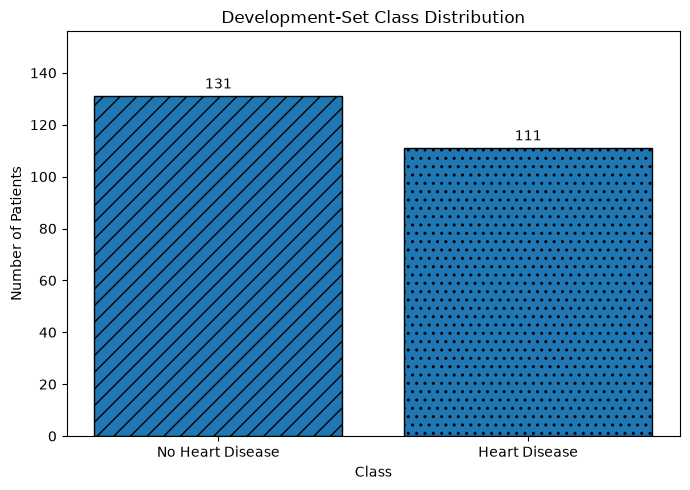

In [8]:
counts = target_balance["Count"]

fig, ax = plt.subplots(figsize=(7, 5))

bars = ax.bar(
    counts.index,
    counts.values,
    edgecolor="black",
    hatch=["//", ".."]
)

for bar, count in zip(bars, counts.values):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 3,
        str(count),
        ha="center"
    )

ax.set_title("Development-Set Class Distribution")
ax.set_ylabel("Number of Patients")
ax.set_xlabel("Class")
ax.set_ylim(0, max(counts.values) + 25)

plt.tight_layout()
plt.show()


<h3 style="color:#009E73;">Development-Set Target Balance</h3>

The development data contains:

- **No Heart Disease:** 131 patients (**54.13%**)
- **Heart Disease:** 111 patients (**45.87%**)

The two classes are reasonably balanced, with no class dominating the development set.

<span style="color:#009E73;"><b>Modeling implication:</b></span>  
Accuracy can provide useful information because the target is relatively balanced. However, accuracy alone will not be sufficient; precision, recall, F1-score, and the confusion matrix will also be reported so that different error types remain visible.

<span style="color:#D55E00;"><b>Decision:</b></span>  
No class-balancing technique will be applied based on the current development-set distribution. Stratification will still be used during validation and cross-validation.


<h3 style="color:#009E73;">Numerical Descriptive Statistics</h3>

Before comparing numerical features with the target, I first want to understand how each feature behaves on its own within the development data.

### Questions

1. Where is the center of each distribution?
2. How widely are observations spread?
3. Are the mean and median noticeably different?
4. Does the IQR rule identify potential outliers?
5. Do those observations require investigation rather than automatic removal?


In [9]:
descriptive_stats = pd.DataFrame(index=numeric_cols)

descriptive_stats["Mean"] = eda_df[numeric_cols].mean()
descriptive_stats["Median"] = eda_df[numeric_cols].median()
descriptive_stats["Variance"] = eda_df[numeric_cols].var()
descriptive_stats["Std"] = eda_df[numeric_cols].std()

descriptive_stats["Q1"] = eda_df[numeric_cols].quantile(0.25)
descriptive_stats["Q3"] = eda_df[numeric_cols].quantile(0.75)

descriptive_stats["IQR"] = (
    descriptive_stats["Q3"]
    - descriptive_stats["Q1"]
)

descriptive_stats["Min"] = eda_df[numeric_cols].min()
descriptive_stats["Max"] = eda_df[numeric_cols].max()

display(
    descriptive_stats
    .round(2)
    .rename_axis("Feature")
)


,Mean,Median,Variance,Std,Q1,Q3,IQR,Min,Max
Feature,,,,,,,,,
age,54.55,56.0,80.95,9.00,48.0,61.00,13.00,29.0,77.0
trestbps,130.96,130.0,310.55,17.62,120.0,140.00,20.00,94.0,200.0
chol,249.84,244.5,2792.79,52.85,212.0,277.75,65.75,126.0,564.0
thalach,149.96,153.5,514.67,22.69,134.5,166.00,31.50,71.0,202.0
oldpeak,1.00,0.8,1.26,1.12,0.0,1.60,1.60,0.0,6.2


In [10]:
outlier_summary = []

for col in numeric_cols:
    q1 = eda_df[col].quantile(0.25)
    q3 = eda_df[col].quantile(0.75)
    iqr = q3 - q1

    lower_bound = q1 - 1.5 * iqr
    upper_bound = q3 + 1.5 * iqr

    outliers = eda_df[
        (eda_df[col] < lower_bound)
        | (eda_df[col] > upper_bound)
    ][col]

    outlier_summary.append({
        "Feature": col,
        "Lower Bound": lower_bound,
        "Upper Bound": upper_bound,
        "Potential Outliers": len(outliers)
    })

outlier_summary = pd.DataFrame(outlier_summary)

display(
    outlier_summary
    .round(2)
    .set_index("Feature")
)


,Lower Bound,Upper Bound,Potential Outliers
Feature,,,
age,28.50,80.50,0
trestbps,90.00,170.00,6
chol,113.38,376.38,5
thalach,87.25,213.25,1
oldpeak,-2.40,4.00,4


<h3 style="color:#009E73;">Descriptive Statistics & Outlier Findings</h3>

The development-set summaries provide an initial view of the center and spread of each numerical feature.

The means and medians are relatively close for several variables, but similarity between mean and median alone is **not sufficient to conclude that a distribution is normal**. Distribution shape must still be inspected visually.

The development-set IQR rule identified:

- `age` → **0** potential outliers
- `trestbps` → **6**
- `chol` → **5**
- `thalach` → **1**
- `oldpeak` → **4**

`trestbps` contains the largest number of development observations outside the IQR-based bounds.

<span style="color:#009E73;"><b>Interpretation:</b></span>  
An IQR outlier is not automatically an incorrect observation. Extreme measurements may represent real and informative patient cases.

<span style="color:#D55E00;"><b>Decision:</b></span>  
No potential outliers will be removed at this stage. Their distributions and individual values will be inspected before any cleaning decision is made.


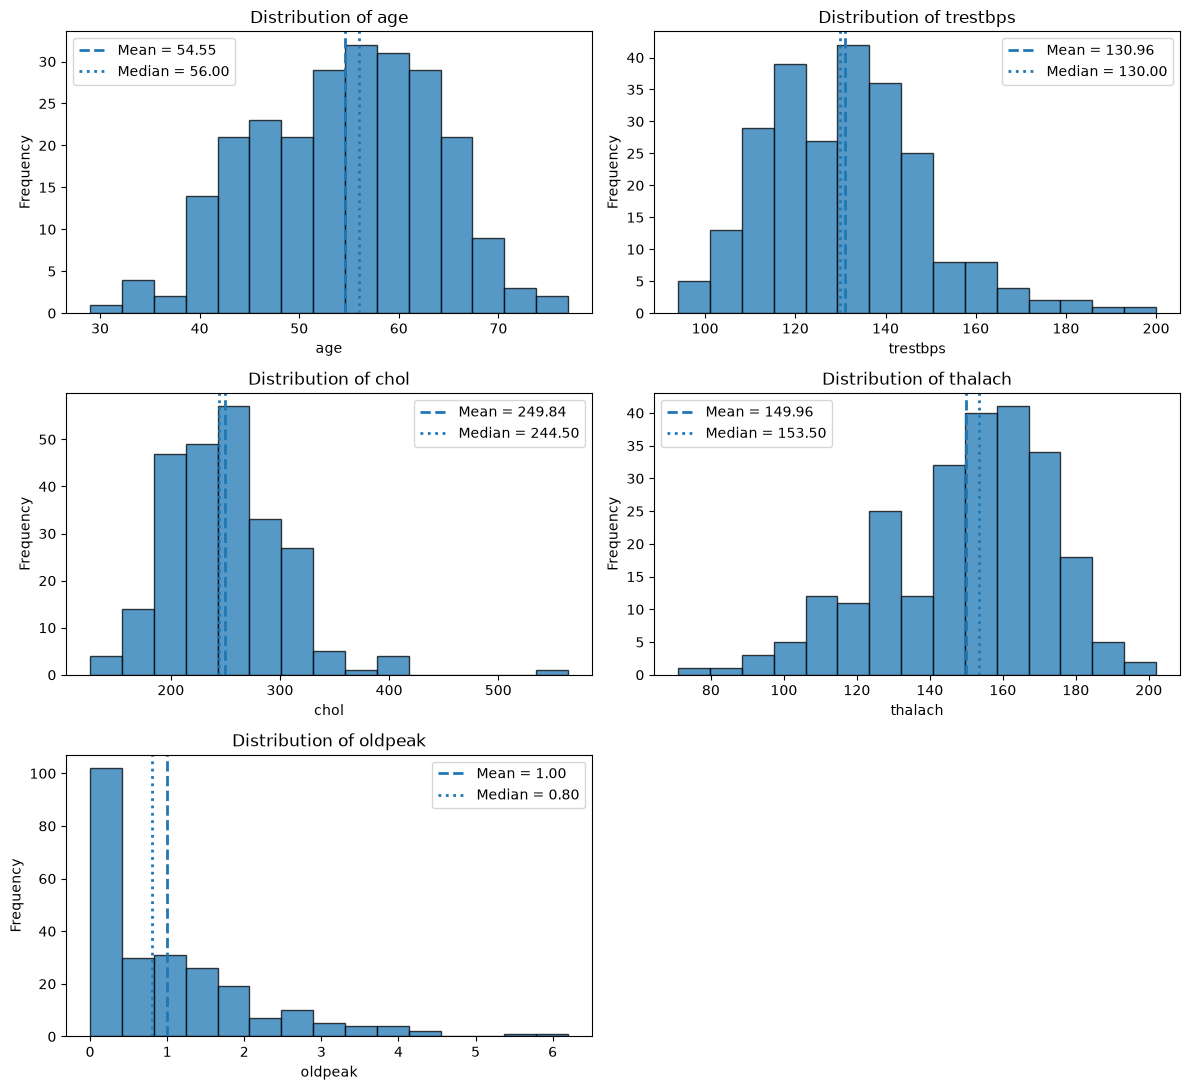

In [11]:
fig, axes = plt.subplots(3, 2, figsize=(12, 11))
axes = axes.flatten()

for i, col in enumerate(numeric_cols):
    ax = axes[i]

    ax.hist(
        eda_df[col].dropna(),
        bins=15,
        edgecolor="black",
        alpha=0.75
    )

    mean_value = eda_df[col].mean()
    median_value = eda_df[col].median()

    ax.axvline(
        mean_value,
        linestyle="--",
        linewidth=2,
        label=f"Mean = {mean_value:.2f}"
    )

    ax.axvline(
        median_value,
        linestyle=":",
        linewidth=2,
        label=f"Median = {median_value:.2f}"
    )

    ax.set_title(f"Distribution of {col}")
    ax.set_xlabel(col)
    ax.set_ylabel("Frequency")
    ax.legend()

axes[-1].axis("off")

plt.tight_layout()
plt.show()


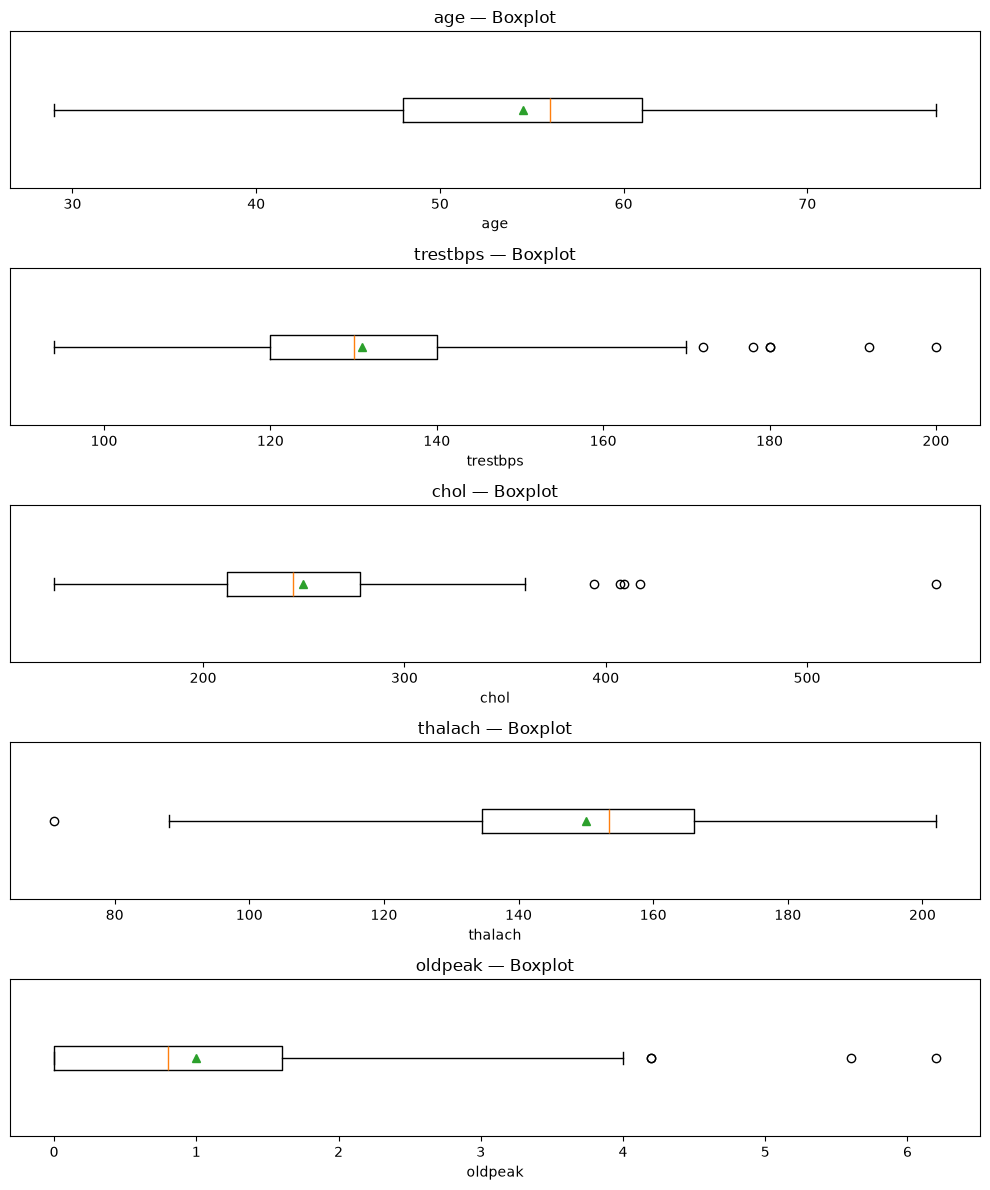

In [12]:
fig, axes = plt.subplots(
    len(numeric_cols),
    1,
    figsize=(10, 12)
)

for ax, col in zip(axes, numeric_cols):

    ax.boxplot(
        eda_df[col].dropna(),
        orientation="horizontal",
        showmeans=True
    )

    ax.set_title(f"{col} — Boxplot")
    ax.set_xlabel(col)
    ax.set_yticks([])

plt.tight_layout()
plt.show()


<h3 style="color:#009E73;">Distribution & Potential-Outlier Interpretation</h3>

The development-set visualizations show that the numerical features do not all have the same distribution shape.

- `age` appears relatively symmetric compared with the other numerical variables.
- `trestbps` shows a longer upper tail with several high observations.
- `chol` is right-skewed and contains several high values, including one particularly isolated observation.
- `thalach` is asymmetric with a longer lower tail, consistent with its mean being lower than its median.
- `oldpeak` shows the clearest right-skewed distribution, with many observations concentrated near low values and a long upper tail.

The boxplots also show that the IQR rule identifies different kinds of potential outliers: some extend gradually from the observed distribution, while others are more isolated.

<span style="color:#D55E00;"><b>Decision:</b></span>  
Statistical extremeness alone is not sufficient evidence for deletion. The flagged development records will be inspected directly.


<h3 style="color:#009E73;">Inspecting Potential Outlier Records</h3>

The IQR rule identified several development observations outside the central range of the numerical features.

Before making any cleaning decision, these observations will be inspected directly.

### Question

Are the potential outliers obviously inconsistent with the dataset, or do they appear to be plausible extreme patient measurements?

<span style="color:#D55E00;"><b>Important:</b></span>  
The IQR rule detects statistical extremeness, not data-entry errors. No observation will be removed solely because it lies outside the IQR bounds.


In [13]:
outlier_records = []

for col in numeric_cols:
    q1 = eda_df[col].quantile(0.25)
    q3 = eda_df[col].quantile(0.75)
    iqr = q3 - q1

    lower_bound = q1 - 1.5 * iqr
    upper_bound = q3 + 1.5 * iqr

    mask = (
        (eda_df[col] < lower_bound)
        | (eda_df[col] > upper_bound)
    )

    for idx in eda_df.index[mask]:
        outlier_records.append({
            "Row": idx,
            "Feature": col,
            "Value": eda_df.loc[idx, col]
        })

outlier_records = pd.DataFrame(outlier_records)

display(
    outlier_records
    .sort_values(["Feature", "Value"])
    .reset_index(drop=True)
)


,Row,Feature,Value
0,173,chol,394.0
1,121,chol,407.0
2,181,chol,409.0
3,48,chol,417.0
4,152,chol,564.0
5,183,oldpeak,4.2
6,191,oldpeak,4.2
7,123,oldpeak,5.6
8,91,oldpeak,6.2
9,245,thalach,71.0


<h3 style="color:#009E73;">Outlier Handling Decision</h3>

The row-level development-set inspection identified **16 feature-level potential outlier observations** across `trestbps`, `chol`, `thalach`, and `oldpeak`.

Some values form a gradual continuation of the observed distribution, while others are more isolated. For example, `chol = 564`, `thalach = 71`, and the highest `oldpeak` values are farther from the central data than many other IQR-flagged observations.

A single patient can also be extreme in more than one feature. For example, row 183 is flagged for both `trestbps` and `oldpeak`; this does not make the record a duplicate or an error.

<span style="color:#009E73;"><b>Interpretation:</b></span>  
The IQR method establishes that these observations are statistically unusual, but neither the dataset documentation nor the current development-set analysis provides evidence that they are invalid measurements.

<span style="color:#D55E00;"><b>Decision:</b></span>  
All potential outlier observations will be retained. Removing them solely because they are statistically extreme could discard real patient information and alter the structure of this relatively small dataset.


<h3 style="color:#009E73;">Categorical & Discrete Feature Distributions</h3>

The next univariate step examines the development-set frequencies of binary, categorical, and discrete features.

The missing values are kept visible rather than silently excluded from the analysis.


In [14]:
category_labels = {
    "sex": {0: "Female", 1: "Male"},
    "cp": {
        1: "Typical Angina",
        2: "Atypical Angina",
        3: "Non-anginal Pain",
        4: "Asymptomatic"
    },
    "fbs": {0: "False", 1: "True"},
    "restecg": {
        0: "Normal",
        1: "ST-T Abnormality",
        2: "LV Hypertrophy"
    },
    "exang": {0: "No", 1: "Yes"},
    "slope": {1: "Upsloping", 2: "Flat", 3: "Downsloping"},
    "thal": {3: "Normal", 6: "Fixed Defect", 7: "Reversible Defect"}
}

categorical_analysis_cols = (
    binary_cols
    + categorical_cols
    + discrete_numeric_cols
)

for col in categorical_analysis_cols:
    counts = (
        eda_df[col]
        .value_counts(dropna=False)
        .sort_index()
    )

    print(f"\n{col}")
    display(
        counts
        .to_frame("Count")
        .rename_axis("Value")
    )



sex


,Count
Value,
0.0,77
1.0,165



fbs


,Count
Value,
0.0,207
1.0,35



exang


...

,Count
Value,
1.0,116
2.0,110
3.0,16



thal


,Count
Value,
3.0,135
6.0,11
7.0,95
NaN,1



ca


,Count
Value,
0.0,147
1.0,53
2.0,29
3.0,12
NaN,1


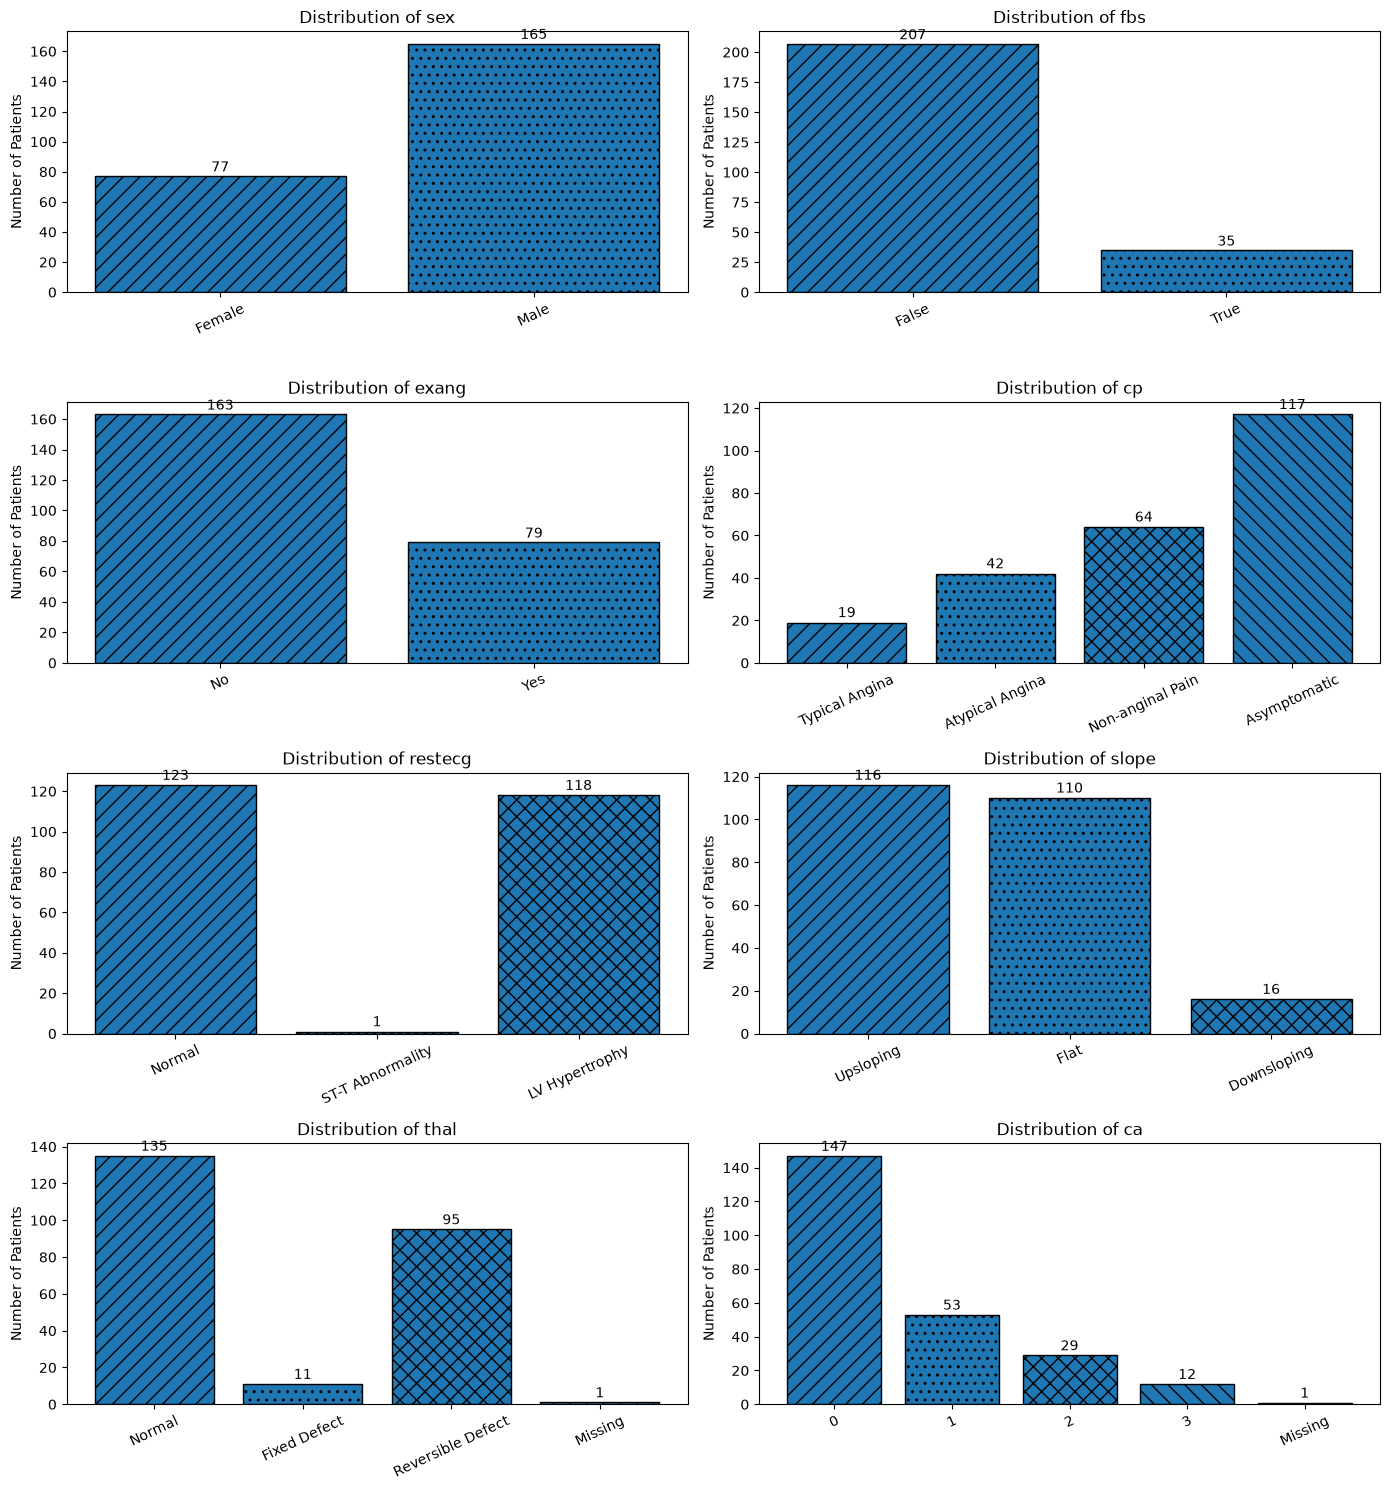

In [15]:
fig, axes = plt.subplots(
    4,
    2,
    figsize=(14, 15)
)

axes = axes.flatten()
hatches = ["//", "..", "xx", "\\\\"]

for ax, col in zip(axes, categorical_analysis_cols):

    counts = eda_df[col].value_counts(dropna=False).sort_index()
    labels = []

    for value in counts.index:
        if pd.isna(value):
            labels.append("Missing")
        elif col in category_labels:
            labels.append(
                category_labels[col].get(
                    int(value),
                    str(int(value))
                )
            )
        else:
            labels.append(str(int(value)))

    bars = ax.bar(
        labels,
        counts.values,
        edgecolor="black"
    )

    for i, bar in enumerate(bars):
        bar.set_hatch(hatches[i % len(hatches)])
        ax.text(
            bar.get_x() + bar.get_width() / 2,
            bar.get_height() + 1,
            str(int(bar.get_height())),
            ha="center",
            va="bottom"
        )

    ax.set_title(f"Distribution of {col}")
    ax.set_ylabel("Number of Patients")
    ax.tick_params(axis="x", rotation=25)

plt.tight_layout()
plt.show()


<h3 style="color:#009E73;">Categorical Feature Distribution Findings</h3>

The development data shows several different categorical/discrete distribution patterns.

- `fbs` is strongly concentrated in the **False** category (**207 vs. 35**).
- `restecg` contains only **1** patient in the ST-T Abnormality category, while Normal and LV Hypertrophy are much more common.
- `slope` is mainly divided between Upsloping (**116**) and Flat (**110**), while Downsloping is uncommon (**16**).
- `cp` is most concentrated in the Asymptomatic category (**117**).
- `ca` is concentrated at 0 (**147**), while values 1–3 occur less frequently.
- `thal` is mainly distributed between Normal (**135**) and Reversible Defect (**95**), with Fixed Defect less frequent (**11**).

Within the development set, `ca` and `thal` each contain **1 missing observation**. The original raw-data audit remains the source for the dataset-wide missing-value totals.

<span style="color:#009E73;"><b>Interpretation:</b></span>  
An imbalanced feature distribution does not automatically require balancing. These frequencies may represent the actual sample structure, while rare categories require cautious interpretation because evidence from very small groups is less stable.

<span style="color:#D55E00;"><b>Modeling decision:</b></span>  
No categorical levels will be removed, merged, or artificially balanced at this stage. Missing-value handling and categorical preprocessing will later be learned from training data within the preprocessing workflow.


<h2 style="color:#0072B2;">5. Bivariate EDA — Numerical Features vs. Heart Disease</h2>

The univariate analysis described how each numerical feature behaves within the development set.

The next question is more directly related to the classification problem:

### Question

Do the numerical measurements show different distributions between patients with and without heart disease?

Only development data is used. The final test set remains untouched.


In [16]:
numeric_by_target = (
    eda_df
    .groupby("heart_disease")[numeric_cols]
    .agg(["mean", "median"])
    .round(2)
)

display(
    numeric_by_target.rename(
        index={
            0: "No Heart Disease",
            1: "Heart Disease"
        }
    )
)


age        trestbps           chol        thalach         \
                   mean median     mean median    mean median    mean median   
heart_disease                                                                  
No Heart Disease  52.82   52.0   128.76  129.0  246.09  240.0  158.50  161.0   
Heart Disease     56.59   58.0   133.56  130.0  254.26  254.0  139.89  142.0   

                 oldpeak         
                    mean median  
heart_disease                    
No Heart Disease    0.59    0.2  
Heart Disease       1.48    1.2

In [17]:
comparison_rows = []

for col in numeric_cols:
    no_disease = eda_df.loc[
        eda_df["heart_disease"] == 0,
        col
    ]

    disease = eda_df.loc[
        eda_df["heart_disease"] == 1,
        col
    ]

    comparison_rows.append({
        "Feature": col,
        "No Disease Median": no_disease.median(),
        "Disease Median": disease.median(),
        "Median Difference": disease.median() - no_disease.median()
    })

numeric_target_comparison = pd.DataFrame(
    comparison_rows
).set_index("Feature")

display(
    numeric_target_comparison.round(2)
)


,No Disease Median,Disease Median,Median Difference
Feature,,,
age,52.0,58.0,6.0
trestbps,129.0,130.0,1.0
chol,240.0,254.0,14.0
thalach,161.0,142.0,-19.0
oldpeak,0.2,1.2,1.0


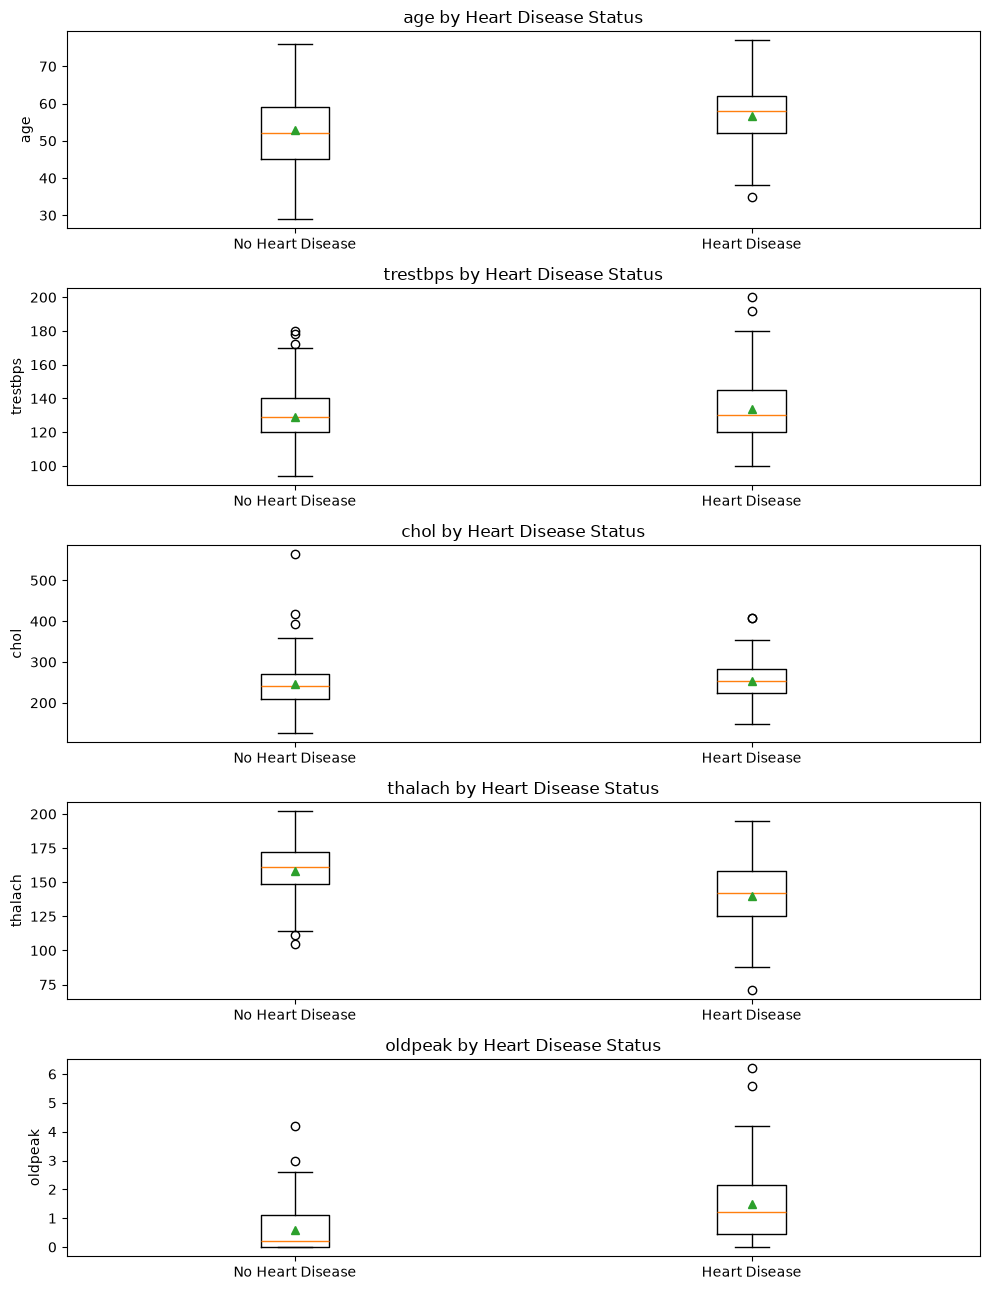

In [18]:
fig, axes = plt.subplots(
    len(numeric_cols),
    1,
    figsize=(10, 13)
)

for ax, col in zip(axes, numeric_cols):

    no_disease = eda_df.loc[
        eda_df["heart_disease"] == 0,
        col
    ].dropna()

    disease = eda_df.loc[
        eda_df["heart_disease"] == 1,
        col
    ].dropna()

    ax.boxplot(
        [no_disease, disease],
        tick_labels=[
            "No Heart Disease",
            "Heart Disease"
        ],
        showmeans=True
    )

    ax.set_title(f"{col} by Heart Disease Status")
    ax.set_ylabel(col)

plt.tight_layout()
plt.show()


<h3 style="color:#009E73;">Numerical Features vs. Heart Disease — Findings</h3>

The numerical features do not show the same degree of separation between the two target groups.

Among the development-set observations:

- `thalach` shows one of the clearest differences. Its median decreases from **161** in patients without heart disease to **142** in patients with heart disease.
- `oldpeak` also shows a noticeable shift, with the median increasing from **0.2** to **1.2** in the heart-disease group.
- `age` shows a moderate difference, with median age increasing from **52** to **58**.
- `chol` has a higher median in the heart-disease group (**254 vs. 240**), but the distributions still overlap substantially.
- `trestbps` shows little median separation (**130 vs. 129**) and considerable overlap between the groups.

<span style="color:#009E73;"><b>Interpretation:</b></span>  
`thalach` and `oldpeak` show the strongest univariate separation among the numerical features examined so far, while `trestbps` appears much less discriminative when considered alone.

These observations describe associations within the development data only. They do not establish causation and do not prove which variables will be most important to a multivariable model.

<span style="color:#D55E00;"><b>Modeling implication:</b></span>  
All numerical features will remain available for modeling. Feature retention will not be decided from a single visualization or median difference alone.


<h2 style="color:#0072B2;">6. Bivariate EDA — Categorical Features vs. Heart Disease</h2>

The previous analysis showed how categorical features are distributed overall.

### Question

Does the proportion of heart disease change across the categories of each feature?

Using proportions rather than raw counts makes comparison easier when category sizes differ. Missing groups remain visible so that observations are not silently excluded.

Only development data is used.


In [19]:
categorical_target_cols = (
    binary_cols
    + categorical_cols
    + discrete_numeric_cols
)

eda_cat = eda_df.copy()

for col in categorical_target_cols:
    eda_cat[col] = (
        eda_cat[col]
        .astype("object")
        .fillna("Missing")
    )

category_target_results = {}

for col in categorical_target_cols:

    table = pd.crosstab(
        eda_cat[col],
        eda_cat["heart_disease"],
        normalize="index"
    ).mul(100)

    table = table.rename(
        columns={
            0: "No Heart Disease (%)",
            1: "Heart Disease (%)"
        }
    )

    category_target_results[col] = table.round(1)

    print(f"\n{col}")
    display(table.round(1))



sex


heart_disease,No Heart Disease (%),Heart Disease (%)
sex,,
0.0,76.6,23.4
1.0,43.6,56.4



fbs


heart_disease,No Heart Disease (%),Heart Disease (%)
fbs,,
0.0,55.1,44.9
1.0,48.6,51.4



exang


...

heart_disease,No Heart Disease (%),Heart Disease (%)
slope,,
1.0,73.3,26.7
2.0,35.5,64.5
3.0,43.8,56.2



thal


heart_disease,No Heart Disease (%),Heart Disease (%)
thal,,
3.0,78.5,21.5
6.0,36.4,63.6
7.0,22.1,77.9
Missing,0.0,100.0



ca


heart_disease,No Heart Disease (%),Heart Disease (%)
ca,,
0.0,72.8,27.2
1.0,32.1,67.9
2.0,20.7,79.3
3.0,8.3,91.7
Missing,0.0,100.0


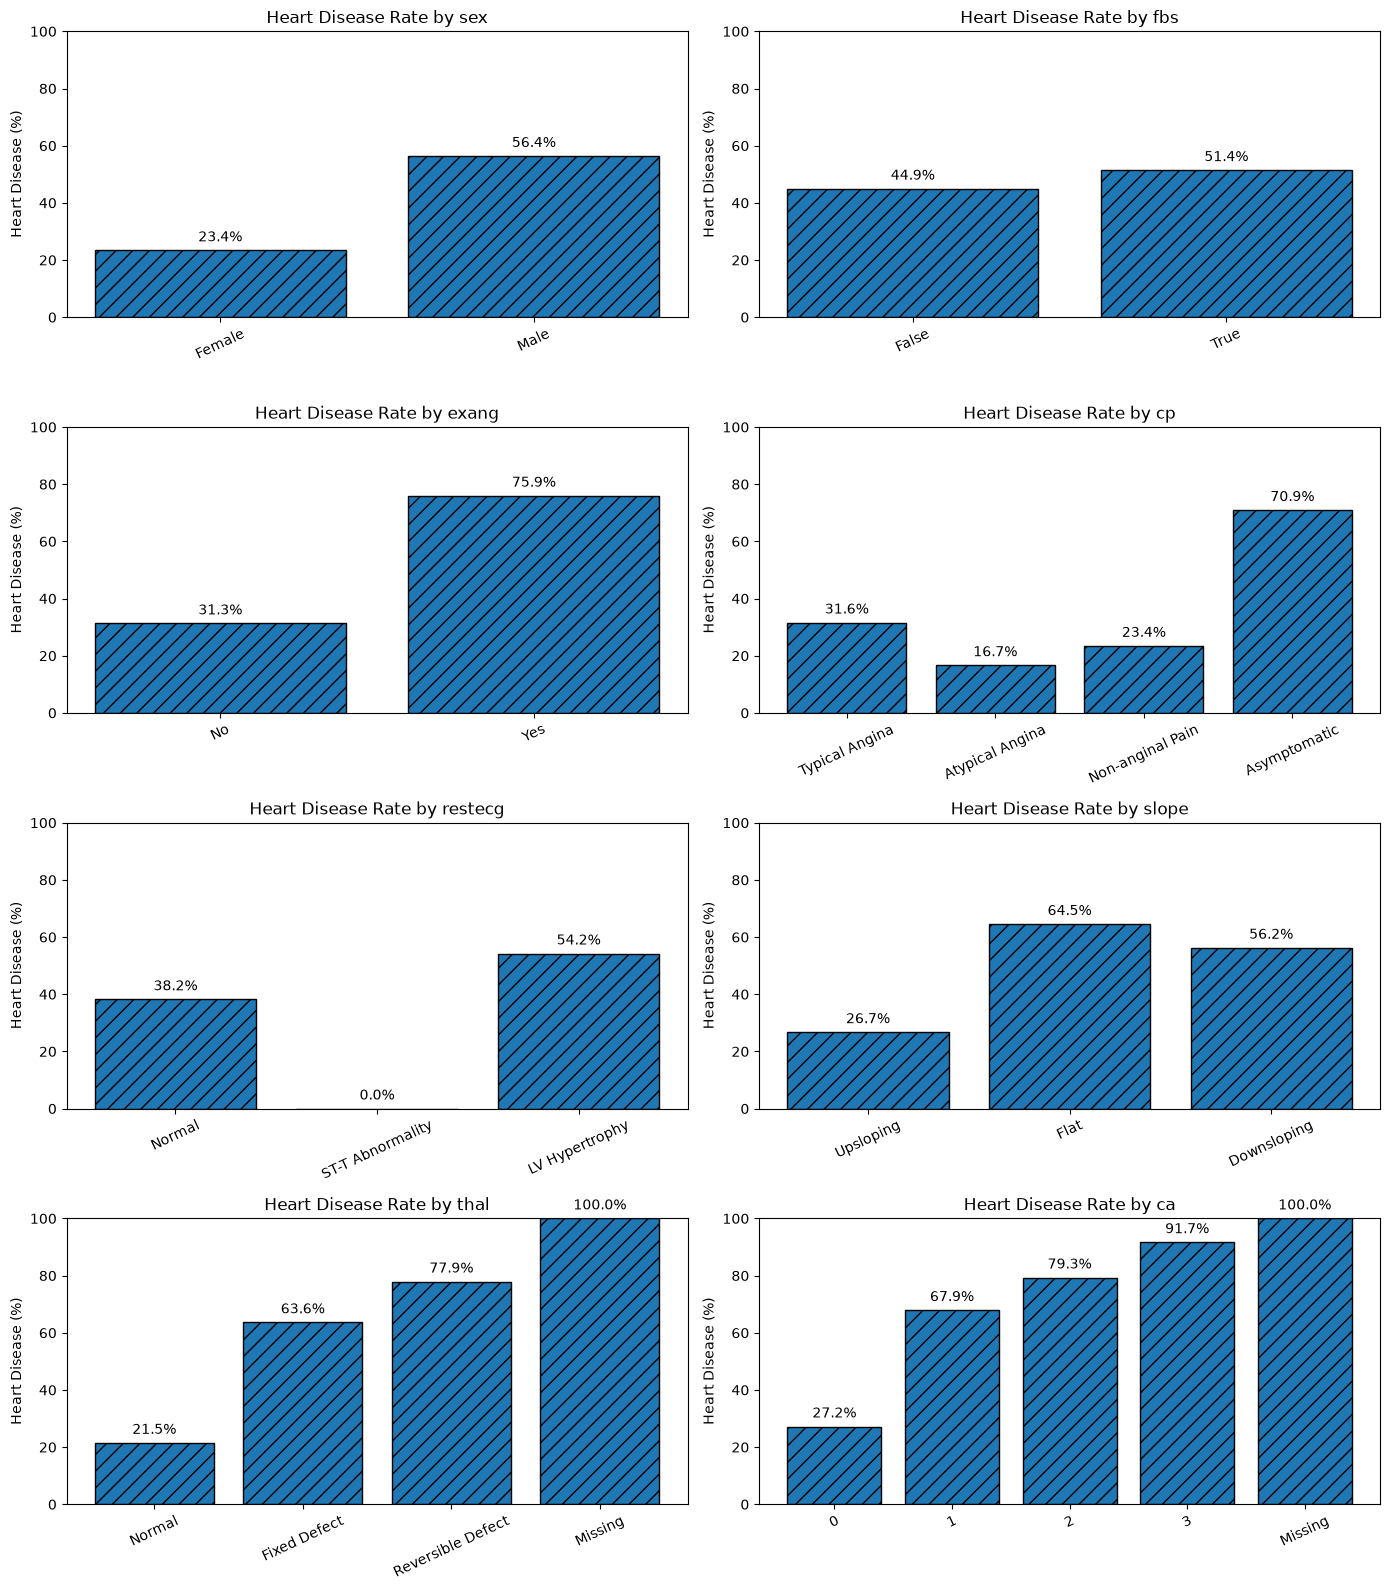

In [20]:
fig, axes = plt.subplots(
    4,
    2,
    figsize=(14, 16)
)

axes = axes.flatten()

for ax, col in zip(axes, categorical_target_cols):

    table = pd.crosstab(
        eda_cat[col],
        eda_cat["heart_disease"],
        normalize="index"
    ).mul(100)

    disease_pct = table.get(
        1,
        pd.Series(
            0,
            index=table.index,
            dtype=float
        )
    )

    labels = []

    for value in disease_pct.index:
        if value == "Missing":
            labels.append("Missing")
        elif col in category_labels:
            labels.append(
                category_labels[col].get(
                    int(value),
                    str(int(value))
                )
            )
        else:
            labels.append(str(int(value)))

    bars = ax.bar(
        labels,
        disease_pct.values,
        edgecolor="black",
        hatch="//"
    )

    for bar, value in zip(bars, disease_pct.values):
        ax.text(
            bar.get_x() + bar.get_width() / 2,
            bar.get_height() + 2,
            f"{value:.1f}%",
            ha="center",
            va="bottom"
        )

    ax.set_title(f"Heart Disease Rate by {col}")
    ax.set_ylabel("Heart Disease (%)")
    ax.set_ylim(0, 100)
    ax.tick_params(axis="x", rotation=25)

plt.tight_layout()
plt.show()


<h3 style="color:#009E73;">Categorical Features vs. Heart Disease — Findings</h3>

The categorical and discrete features show substantially different levels of association with heart-disease status in the development data.

Several patterns are especially notable:

- `ca` shows a strong ordered pattern: the observed heart-disease rate rises from **27.2%** at `ca = 0` to **67.9%**, **79.3%**, and **91.7%** at values 1, 2, and 3.
- `thal` shows substantial separation: **21.5%** for Normal, **63.6%** for Fixed Defect, and **77.9%** for Reversible Defect.
- `exang` shows a clear difference: **31.3%** without exercise-induced angina versus **75.9%** when it is present.
- `cp` shows a particularly high disease proportion in the Asymptomatic category (**70.9%**).
- Sex and slope also show noticeable category differences.
- `fbs` shows relatively little separation (**44.9% vs. 51.4%**).

<span style="color:#E69F00;"><b>Caution with small groups:</b></span>  
Large percentages are not automatically strong evidence when calculated from very small groups. This is especially important for the rare ST-T Abnormality category and for the missing-value groups in `ca` and `thal`. Each missing group contains only one development observation, so its observed **100%** disease rate is not stable evidence.

<span style="color:#009E73;"><b>Key insight:</b></span>  
The current EDA suggests that `ca`, `thal`, `exang`, and `cp` may contain stronger univariate signal than features such as `fbs`. These are development-set associations, not measures of final model importance.

<span style="color:#D55E00;"><b>Modeling decision:</b></span>  
No feature will be removed based only on these bivariate comparisons. All documented features will initially remain available for modeling.


<h2 style="color:#0072B2;">7. Correlation Analysis</h2>

Correlation analysis will be used to examine linear relationships among features that have a meaningful numerical interpretation.

Multi-category variables such as `cp`, `restecg`, `slope`, and `thal` are excluded because their numeric values are category codes rather than continuous measurements.

The analysis includes:

- continuous numerical measurements,
- `ca` as a discrete numeric count,
- and the binary `heart_disease` target for exploratory comparison.

### Questions

1. Are any numerical features strongly correlated with each other?
2. Which numerical features show the strongest linear association with the binary target?
3. Could strong feature-to-feature correlation create redundant information for some models?

<span style="color:#D55E00;"><b>Important:</b></span>  
Correlation describes association, not causation, and a weak linear correlation does not mean that a feature contains no predictive information.


In [21]:
correlation_cols = (
    numeric_cols
    + discrete_numeric_cols
    + ["heart_disease"]
)

correlation_matrix = (
    eda_df[correlation_cols]
    .corr()
    .round(2)
)

display(correlation_matrix)


,age,trestbps,chol,thalach,oldpeak,ca,heart_disease
age,1.00,0.28,0.23,-0.40,0.22,0.35,0.21
trestbps,0.28,1.00,0.16,-0.03,0.23,0.09,0.14
chol,0.23,0.16,1.00,-0.02,0.02,0.14,0.08
thalach,-0.40,-0.03,-0.02,1.00,-0.38,-0.27,-0.41
oldpeak,0.22,0.23,0.02,-0.38,1.00,0.30,0.39
ca,0.35,0.09,0.14,-0.27,0.30,1.00,0.45
heart_disease,0.21,0.14,0.08,-0.41,0.39,0.45,1.00


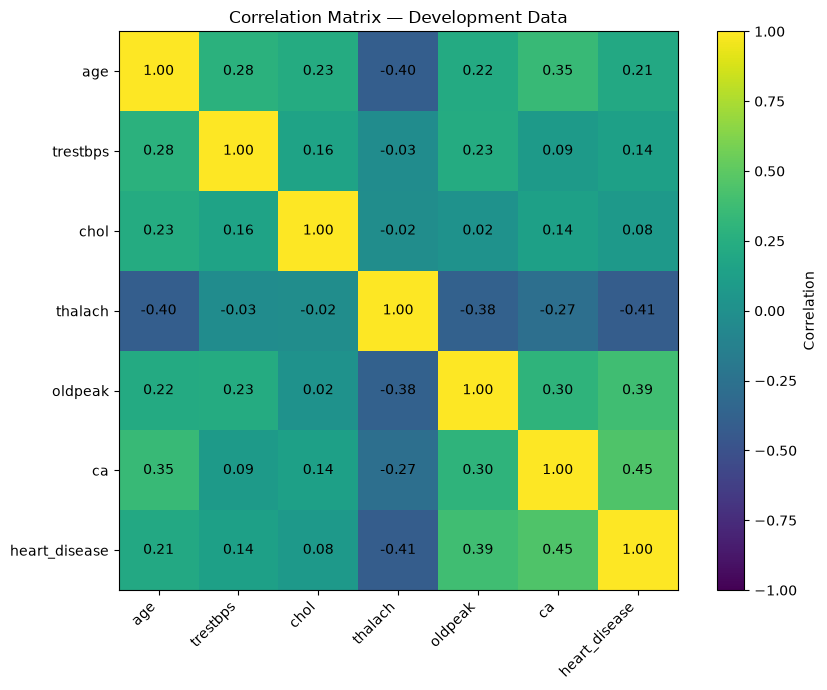

In [22]:
fig, ax = plt.subplots(figsize=(9, 7))

image = ax.imshow(
    correlation_matrix,
    vmin=-1,
    vmax=1
)

ax.set_xticks(range(len(correlation_matrix.columns)))
ax.set_yticks(range(len(correlation_matrix.index)))

ax.set_xticklabels(
    correlation_matrix.columns,
    rotation=45,
    ha="right"
)

ax.set_yticklabels(
    correlation_matrix.index
)

for i in range(len(correlation_matrix.index)):
    for j in range(len(correlation_matrix.columns)):
        value = correlation_matrix.iloc[i, j]

        ax.text(
            j,
            i,
            f"{value:.2f}",
            ha="center",
            va="center"
        )

ax.set_title("Correlation Matrix — Development Data")

fig.colorbar(
    image,
    ax=ax,
    label="Correlation"
)

plt.tight_layout()
plt.show()


In [23]:
target_correlations = (
    correlation_matrix["heart_disease"]
    .drop("heart_disease")
    .sort_values(
        key=abs,
        ascending=False
    )
    .to_frame("Correlation with Heart Disease")
)

display(target_correlations)


,Correlation with Heart Disease
ca,0.45
thalach,-0.41
oldpeak,0.39
age,0.21
trestbps,0.14
chol,0.08


<h3 style="color:#009E73;">Correlation Findings</h3>

The correlation analysis supports several patterns already observed during the bivariate EDA.

Among the numerical and discrete features:

- `ca` shows the strongest positive linear association with heart-disease status (**r = 0.45**).
- `thalach` shows the strongest negative association (**r = -0.41**).
- `oldpeak` also shows a noticeable positive association (**r = 0.39**).
- `age` has a weaker positive association (**r = 0.21**).
- `trestbps` (**r = 0.14**) and `chol` (**r = 0.08**) show relatively weak linear associations with the binary target.

<span style="color:#009E73;"><b>Feature-to-feature relationships:</b></span>  
No analyzed predictor pair shows an extremely strong correlation. Larger observed relationships include `age` with `thalach` (**-0.40**), `thalach` with `oldpeak` (**-0.38**), `age` with `ca` (**0.35**), and `oldpeak` with `ca` (**0.30**).

<span style="color:#E69F00;"><b>Interpretation caution:</b></span>  
Because `heart_disease` is binary, its Pearson correlation with a numerical variable describes linear association with the two target groups. Correlation does not establish causation, and low correlation does not prove that a feature is useless; non-linear relationships and feature interactions may still matter.

<span style="color:#D55E00;"><b>Decision:</b></span>  
No feature will be removed based on the correlation matrix. All documented features will remain available for the initial modeling stage.


<h2 style="color:#0072B2;">EDA Checkpoint — Evidence Before Modeling</h2>

The exploratory analysis has established a clear evidence base for the modeling stage.

### Data Quality

The raw dataset contains no duplicate records. Six non-standard missing markers were identified and standardized as `NaN`: four in `ca` and two in `thal`. This marker standardization is deterministic schema cleaning; imputation has **not** been learned from the full dataset.

Potential numerical outliers were investigated on the development set using the IQR rule. No observation was removed because the available evidence does not establish that the flagged values are invalid.

### Leakage Control

A stratified final hold-out set of **61 patients** was isolated before distribution-based EDA and target-driven analysis. All EDA decisions after the split use the **242-patient development set** only.

### Target

The development target is reasonably balanced:

- **No Heart Disease:** 131 patients (**54.13%**)
- **Heart Disease:** 111 patients (**45.87%**)

No class-balancing technique is currently justified. Stratification will be maintained during validation.

### Numerical Signal

The clearest numerical separation in the development data appears in `thalach` and `oldpeak`, with `age` showing a more moderate difference. `trestbps` and `chol` show greater overlap when considered individually.

### Categorical / Discrete Signal

The clearest category-level differences appear in `ca`, `thal`, `exang`, and `cp`. Rare categories and missing groups are interpreted cautiously because percentages based on very small groups are unstable.

### Correlation

Among the numerical/discrete variables examined, `ca`, `thalach`, and `oldpeak` show the strongest linear associations with the binary target. No severe feature-to-feature correlation was observed that currently justifies removing a predictor.

<span style="color:#009E73;"><b>Modeling direction:</b></span>  
Useful predictive information appears across both numerical and categorical features. The initial supervised-learning stage should therefore preserve the full documented feature set and apply preprocessing according to feature meaning rather than selecting variables solely from univariate EDA.

<span style="color:#D55E00;"><b>Evaluation discipline:</b></span>  
The final test set remains reserved for one final evaluation after model selection and feature engineering. It will not be used to choose preprocessing steps, features, or models.


<h2 style="color:#0072B2;">8. Supervised Learning Strategy</h2>

The EDA is now complete, so the next question is whether the observed patterns can be learned reliably by a supervised classification model.

### What the EDA tells us before modeling

The dataset contains a mixture of:

- continuous numerical measurements such as `age`, `trestbps`, `chol`, `thalach`, and `oldpeak`,
- binary indicators such as `sex`, `fbs`, and `exang`,
- categorical variables stored using numeric codes such as `cp`, `restecg`, `slope`, and `thal`,
- and `ca`, which represents an ordered discrete count from 0 to 3.

The EDA also showed that predictive information is not concentrated in one feature. Numerical features such as `thalach` and `oldpeak` showed useful separation, while categorical/discrete features such as `ca`, `thal`, `exang`, and `cp` also showed noticeable relationships with the target.

### Modeling Question

Can these different types of patient information be combined to classify heart-disease presence better than a simple supervised baseline?

### Initial Models

**Logistic Regression** will be used as the initial supervised baseline.

It provides a relatively simple linear decision model and gives us a useful reference before testing a more flexible classifier.

**Random Forest** will be used as the first comparison model.

Unlike Logistic Regression, Random Forest can capture non-linear relationships and interactions without requiring the relationship between each feature and the target to be linear.

<span style="color:#009E73;"><b>Reason for this comparison:</b></span>  
The goal is not to test as many algorithms as possible. The goal is to compare two models with meaningfully different assumptions and determine which better matches the structure observed in this dataset.

<span style="color:#D55E00;"><b>Evaluation discipline:</b></span>  
The final test set remains untouched. Model development and comparison will continue only with the development data.

In [24]:
RANDOM_STATE = 42

X_train, X_val, y_train, y_val = train_test_split(
    X_dev,
    y_dev,
    test_size=0.25,
    random_state=RANDOM_STATE,
    stratify=y_dev
)

development_split = pd.DataFrame({
    "Samples": [
        len(y_train),
        len(y_val)
    ],
    "Heart Disease (%)": [
        y_train.mean() * 100,
        y_val.mean() * 100
    ]
}, index=[
    "Training",
    "Validation"
])

display(development_split.round(2))

print("Final test set remains reserved:", X_test.shape)

,Samples,Heart Disease (%)
Training,181,45.86
Validation,61,45.90


Final test set remains reserved: (61, 13)


<h2 style="color:#0072B2;">9. Preprocessing Based on Feature Meaning</h2>

The dataset should not be preprocessed according to Pandas data types alone.

The earlier data audit showed that several variables are stored numerically even though they represent categories. Therefore, preprocessing will follow the documented meaning of each feature.

### Continuous / Ordered Numerical Features

`age`, `trestbps`, `chol`, `thalach`, `oldpeak`, and `ca`

These variables contain meaningful numerical magnitude.

- `ca` is retained as numerical because it represents the number of major vessels from 0 to 3, rather than an arbitrary category code.
- Missing numerical values will be imputed using the training-set median.
- Numerical values will be standardized for models such as Logistic Regression whose behavior depends on feature scale.

### Binary Features

`sex`, `fbs`, and `exang`

These are already represented as 0/1 indicators and do not require one-hot encoding.

### Multi-Category Features

`cp`, `restecg`, `slope`, and `thal`

Although stored using numbers, these values represent categories rather than ordinary numerical distances.

They will therefore be one-hot encoded rather than treated as continuous measurements.

`thal` also contains missing observations, so its missing values will be handled within the training preprocessing workflow.

<span style="color:#009E73;"><b>Key modeling decision:</b></span>  
The preprocessing design follows the semantic meaning discovered during dataset inspection, not simply the column data types.

<span style="color:#D55E00;"><b>Leakage-control decision:</b></span>  
Imputation, scaling, and encoding will be fitted through a Scikit-learn Pipeline so that validation and test observations cannot influence the learned preprocessing parameters.

In [25]:
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler


numeric_model_cols = [
    "age",
    "trestbps",
    "chol",
    "thalach",
    "oldpeak",
    "ca"
]

binary_model_cols = [
    "sex",
    "fbs",
    "exang"
]

categorical_model_cols = [
    "cp",
    "restecg",
    "slope",
    "thal"
]


def build_preprocessor(numeric_columns=None):
    """Create a fresh preprocessing workflow for a model pipeline."""

    if numeric_columns is None:
        numeric_columns = numeric_model_cols

    numeric_pipeline = Pipeline([
        (
            "imputer",
            SimpleImputer(strategy="median")
        ),
        (
            "scaler",
            StandardScaler()
        )
    ])

    categorical_pipeline = Pipeline([
        (
            "imputer",
            SimpleImputer(strategy="most_frequent")
        ),
        (
            "onehot",
            OneHotEncoder(handle_unknown="ignore")
        )
    ])

    return ColumnTransformer([
        (
            "numeric",
            numeric_pipeline,
            numeric_columns
        ),
        (
            "binary",
            "passthrough",
            binary_model_cols
        ),
        (
            "categorical",
            categorical_pipeline,
            categorical_model_cols
        )
    ])


print("Numeric:", numeric_model_cols)
print("Binary:", binary_model_cols)
print("Categorical:", categorical_model_cols)

Numeric: ['age', 'trestbps', 'chol', 'thalach', 'oldpeak', 'ca']
Binary: ['sex', 'fbs', 'exang']
Categorical: ['cp', 'restecg', 'slope', 'thal']


<h2 style="color:#0072B2;">10. Supervised Baseline — Logistic Regression</h2>

The first supervised model will be Logistic Regression.

### Why start with Logistic Regression?

A baseline should be simple enough to provide a clear reference for later comparison.

After preprocessing:

- continuous and ordered numerical information is represented on comparable scales,
- binary variables retain their 0/1 meaning,
- and multi-category variables are represented using one-hot encoding.

Logistic Regression can therefore combine all documented feature groups into an initial linear classification model.

### Question

How well can a relatively simple linear decision model separate patients with and without documented heart disease?

This result will become the reference against which the more flexible comparison model is evaluated.

In [26]:
from sklearn.linear_model import LogisticRegression

logistic_pipeline = Pipeline([
    (
        "preprocessor",
        build_preprocessor()
    ),
    (
        "model",
        LogisticRegression(
            max_iter=1000
        )
    )
])

logistic_pipeline.fit(
    X_train,
    y_train
)

logistic_train_pred = logistic_pipeline.predict(
    X_train
)

logistic_val_pred = logistic_pipeline.predict(
    X_val
)

print("Logistic Regression trained successfully.")

Logistic Regression trained successfully.


<h2 style="color:#0072B2;">11. Comparison Model — Random Forest</h2>

Logistic Regression provides a useful linear baseline, but the EDA does not establish that all relationships in the dataset are linear.

Several variables showed different patterns across categories, and useful information appears across multiple feature groups rather than through one measurement alone.

Random Forest is therefore selected as the comparison model because it can:

- represent non-linear decision boundaries,
- combine information through feature interactions,
- and model different regions of the feature space without requiring one global linear relationship.

### Comparison Question

Does the added flexibility of Random Forest improve validation performance enough to justify using a more complex model?

The answer will be based on evaluation evidence rather than model complexity alone.

In [27]:
from sklearn.ensemble import RandomForestClassifier

random_forest_pipeline = Pipeline([
    (
        "preprocessor",
        build_preprocessor()
    ),
    (
        "model",
        RandomForestClassifier(
            n_estimators=100,
            random_state=RANDOM_STATE
        )
    )
])

random_forest_pipeline.fit(
    X_train,
    y_train
)

rf_train_pred = random_forest_pipeline.predict(
    X_train
)

rf_val_pred = random_forest_pipeline.predict(
    X_val
)

print("Random Forest trained successfully.")

Random Forest trained successfully.


<h2 style="color:#0072B2;">12. Initial Validation Comparison</h2>

Training a model is not sufficient; its predictions must be evaluated against unseen development data.

The target distribution is reasonably balanced, so accuracy remains useful. However, different classification errors must still remain visible.

The initial comparison will therefore examine:

- Accuracy
- Precision
- Recall
- F1-score
- confusion-matrix counts

### Primary model-selection metric

**F1-score** will be used as the primary metric for model comparison because it balances precision and recall for the positive **Heart Disease** class.

Accuracy remains useful because the classes are reasonably balanced, while recall is reported separately so that missed positive cases remain visible rather than being hidden inside one aggregate score.

No model decision will be based on a single metric alone; F1 provides the main comparison criterion, while the confusion matrix, recall, and later ROC-AUC analysis provide supporting evidence.

Performance will be measured on both the training and validation sets.

### Why compare training and validation performance?

A model that performs extremely well on its training observations but substantially worse on validation data may be fitting the training data too closely.

This comparison therefore provides the first evidence for later bias-variance analysis.

In [28]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix
)


def calculate_metrics(y_true, y_pred):
    return {
        "Accuracy": accuracy_score(
            y_true,
            y_pred
        ),
        "Precision": precision_score(
            y_true,
            y_pred,
            zero_division=0
        ),
        "Recall": recall_score(
            y_true,
            y_pred,
            zero_division=0
        ),
        "F1": f1_score(
            y_true,
            y_pred,
            zero_division=0
        )
    }


results = []

for model_name, train_pred, val_pred in [
    (
        "Logistic Regression",
        logistic_train_pred,
        logistic_val_pred
    ),
    (
        "Random Forest",
        rf_train_pred,
        rf_val_pred
    )
]:

    train_metrics = calculate_metrics(
        y_train,
        train_pred
    )

    val_metrics = calculate_metrics(
        y_val,
        val_pred
    )

    results.append({
        "Model": model_name,
        "Train Accuracy": train_metrics["Accuracy"],
        "Validation Accuracy": val_metrics["Accuracy"],
        "Train Precision": train_metrics["Precision"],
        "Validation Precision": val_metrics["Precision"],
        "Train Recall": train_metrics["Recall"],
        "Validation Recall": val_metrics["Recall"],
        "Train F1": train_metrics["F1"],
        "Validation F1": val_metrics["F1"]
    })


initial_model_results = (
    pd.DataFrame(results)
    .set_index("Model")
)

display(
    initial_model_results.round(3)
)

,Train Accuracy,Validation Accuracy,Train Precision,Validation Precision,Train Recall,Validation Recall,Train F1,Validation F1
Model,,,,,,,,
Logistic Regression,0.845,0.803,0.857,0.786,0.795,0.786,0.825,0.786
Random Forest,1.000,0.820,1.000,0.793,1.000,0.821,1.000,0.807


<h3 style="color:#009E73;">Initial Model Comparison — Interpretation</h3>

Random Forest achieved slightly stronger validation performance than Logistic Regression, including a higher validation F1-score.

However, Random Forest also achieved perfect training performance while performing noticeably lower on the validation set. This large train-validation gap suggests possible overfitting.

Logistic Regression showed a smaller gap between training and validation performance, indicating more stable behavior, but its validation performance was slightly weaker.

<span style="color:#009E73;"><b>Current decision:</b></span>  
Random Forest remains the leading model at this stage because it performed better on unseen validation data.

<span style="color:#E69F00;"><b>Remaining question:</b></span>  
Because this conclusion is based on a single validation split and Random Forest shows possible overfitting, the next step is to use cross-validation to determine whether its advantage is stable across different subsets of the development data.

<h2 style="color:#0072B2;">13. Cross-Validation — Testing Model Stability</h2>

The initial comparison relied on one training/validation split.

That split provided useful evidence, but a model may perform unusually well or poorly depending on which observations happened to enter the validation set.

### Question

Is Random Forest consistently stronger than Logistic Regression, or was its validation advantage dependent on the particular split?

To investigate this, both pipelines will be evaluated using **5-fold Stratified Cross-Validation** on the **181-sample training subset**.

### Why keep the validation set outside cross-validation?

The separate validation subset is intentionally preserved for development-stage diagnostics such as confusion-matrix analysis, ROC-AUC comparison, and the controlled feature-engineering experiment.

Therefore, cross-validation is performed on `X_train` and `y_train` rather than on all 242 development observations.

This is a deliberate trade-off: the cross-validation estimate uses fewer observations, but the workflow retains an independent validation set for analyses that require actual held-out predictions.

### Why stratification matters here

The target contains two classes with similar but not identical proportions.

`StratifiedKFold` keeps approximately the same class distribution in every fold, reducing the chance that one fold becomes unusually easy or difficult simply because of class composition.

### Why cross-validate the full Pipeline?

Each model includes preprocessing steps such as imputation, scaling, and one-hot encoding.

Cross-validating the complete Pipeline ensures that these transformations are fitted only on the training portion of each fold.

<span style="color:#D55E00;"><b>Leakage-control decision:</b></span>  
The validation set and final test set are not used to fit any cross-validation fold.

In [29]:
from sklearn.model_selection import (
    StratifiedKFold,
    cross_val_score
)


cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=RANDOM_STATE
)


cv_models = {
    "Logistic Regression": logistic_pipeline,
    "Random Forest": random_forest_pipeline
}


cv_results = []


for model_name, pipeline in cv_models.items():

    scores = cross_val_score(
        pipeline,
        X_train,
        y_train,
        cv=cv,
        scoring="f1"
    )

    cv_results.append({
        "Model": model_name,
        "Fold 1": scores[0],
        "Fold 2": scores[1],
        "Fold 3": scores[2],
        "Fold 4": scores[3],
        "Fold 5": scores[4],
        "Mean CV F1": scores.mean(),
        "Std CV F1": scores.std()
    })


cv_results = (
    pd.DataFrame(cv_results)
    .set_index("Model")
)


display(
    cv_results.round(3)
)

,Fold 1,Fold 2,Fold 3,Fold 4,Fold 5,Mean CV F1,Std CV F1
Model,,,,,,,
Logistic Regression,0.788,0.839,0.789,0.875,0.667,0.792,0.070
Random Forest,0.688,0.800,0.737,0.800,0.727,0.750,0.044


In [30]:
validation_vs_cv = pd.DataFrame({
    "Single Validation F1": [
        initial_model_results.loc[
            "Logistic Regression",
            "Validation F1"
        ],
        initial_model_results.loc[
            "Random Forest",
            "Validation F1"
        ]
    ],

    "Mean CV F1": [
        cv_results.loc[
            "Logistic Regression",
            "Mean CV F1"
        ],
        cv_results.loc[
            "Random Forest",
            "Mean CV F1"
        ]
    ],

    "CV F1 Std": [
        cv_results.loc[
            "Logistic Regression",
            "Std CV F1"
        ],
        cv_results.loc[
            "Random Forest",
            "Std CV F1"
        ]
    ]
}, index=[
    "Logistic Regression",
    "Random Forest"
])


display(
    validation_vs_cv.round(3)
)

,Single Validation F1,Mean CV F1,CV F1 Std
Logistic Regression,0.786,0.792,0.070
Random Forest,0.807,0.750,0.044


<h3 style="color:#009E73;">Cross-Validation Findings & Updated Decision</h3>

The cross-validation results changed the conclusion suggested by the single validation split.

Random Forest had achieved the higher single-validation F1-score (**0.807 vs. 0.786**). However, across five stratified folds, Logistic Regression achieved the higher mean F1-score:

- **Logistic Regression:** Mean CV F1 = **0.792**
- **Random Forest:** Mean CV F1 = **0.750**

Random Forest had the lower standard deviation (**0.044 vs. 0.070**), meaning its fold scores varied less. However, this stability occurred around a lower average performance level.

The Random Forest result also supports the earlier overfitting concern. Its training F1-score was **1.000**, while its mean cross-validated F1-score decreased to **0.750**.

Logistic Regression showed a substantially smaller gap between its training F1-score (**0.825**) and mean cross-validated F1-score (**0.792**).

<span style="color:#009E73;"><b>Updated decision:</b></span>  
Logistic Regression becomes the current leading model because it provides the stronger average generalization performance across multiple training/validation folds.

<span style="color:#E69F00;"><b>Remaining issue:</b></span>  
Its cross-validation scores still vary across folds, including a noticeably weaker fifth fold. Therefore, the model should not be considered final based on mean F1 alone. The next step is to inspect the actual classification errors and discrimination performance before moving to feature engineering.

<h2 style="color:#0072B2;">14. Classification Error Analysis</h2>

Cross-validation provides a stronger estimate of generalization, but a single summary score does not explain how the classifiers make mistakes.

The next analysis returns to the held-out **validation set** to inspect the actual prediction errors produced by each model.

### Questions

1. How many positive and negative cases are classified correctly?
2. How many false positives and false negatives does each model produce?
3. Does one model obtain its score by favoring one class over the other?
4. Do the error patterns support the model preference suggested by cross-validation?

The final test set remains untouched.

In [31]:
from sklearn.metrics import confusion_matrix

validation_predictions = {
    "Logistic Regression": logistic_val_pred,
    "Random Forest": rf_val_pred
}

confusion_results = []

for model_name, predictions in validation_predictions.items():

    tn, fp, fn, tp = confusion_matrix(
        y_val,
        predictions
    ).ravel()

    confusion_results.append({
        "Model": model_name,
        "True Negatives": tn,
        "False Positives": fp,
        "False Negatives": fn,
        "True Positives": tp
    })

confusion_results = (
    pd.DataFrame(confusion_results)
    .set_index("Model")
)

display(confusion_results)

,True Negatives,False Positives,False Negatives,True Positives
Model,,,,
Logistic Regression,27,6,6,22
Random Forest,27,6,5,23


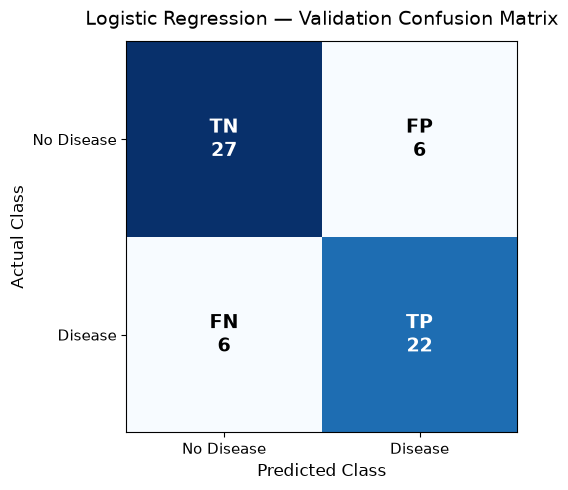

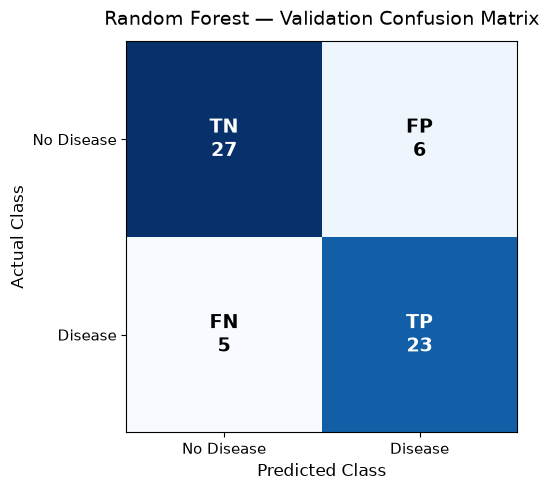

In [32]:
def plot_confusion_matrix_readable(cm, title):
    cell_labels = np.array([
        ["TN", "FP"],
        ["FN", "TP"]
    ])

    class_labels = [
        "No Disease",
        "Disease"
    ]

    fig, ax = plt.subplots(figsize=(6, 5))

    ax.imshow(
        cm,
        cmap="Blues"
    )

    threshold = cm.max() / 2

    for row in range(2):
        for col in range(2):
            text_color = (
                "white"
                if cm[row, col] > threshold
                else "black"
            )

            ax.text(
                col,
                row,
                f"{cell_labels[row, col]}\n{cm[row, col]}",
                ha="center",
                va="center",
                color=text_color,
                fontsize=14,
                fontweight="bold"
            )

    ax.set_xticks([0, 1])
    ax.set_yticks([0, 1])

    ax.set_xticklabels(
        class_labels,
        fontsize=11
    )

    ax.set_yticklabels(
        class_labels,
        fontsize=11
    )

    ax.set_xlabel(
        "Predicted Class",
        fontsize=12
    )

    ax.set_ylabel(
        "Actual Class",
        fontsize=12
    )

    ax.set_title(
        title,
        fontsize=14,
        pad=12
    )

    plt.tight_layout()
    plt.show()


for model_name, predictions in validation_predictions.items():

    cm = confusion_matrix(
        y_val,
        predictions
    )

    plot_confusion_matrix_readable(
        cm,
        f"{model_name} — Validation Confusion Matrix"
    )


In [33]:
from sklearn.metrics import roc_auc_score


logistic_val_score = (
    logistic_pipeline
    .predict_proba(X_val)[:, 1]
)

rf_val_score = (
    random_forest_pipeline
    .predict_proba(X_val)[:, 1]
)


roc_auc_results = pd.DataFrame({
    "ROC-AUC": [
        roc_auc_score(
            y_val,
            logistic_val_score
        ),
        roc_auc_score(
            y_val,
            rf_val_score
        )
    ]
}, index=[
    "Logistic Regression",
    "Random Forest"
])


display(
    roc_auc_results.round(3)
)

,ROC-AUC
Logistic Regression,0.936
Random Forest,0.893


<h3 style="color:#009E73;">Classification Error Analysis — Interpretation</h3>

The validation confusion matrices reveal that the two models make very similar numbers of classification errors.

For Logistic Regression:

- **27** no-disease cases were correctly classified.
- **6** no-disease cases were incorrectly classified as disease.
- **6** disease cases were missed.
- **22** disease cases were correctly identified.

For Random Forest:

- **27** no-disease cases were correctly classified.
- **6** no-disease cases were incorrectly classified as disease.
- **5** disease cases were missed.
- **23** disease cases were correctly identified.

Random Forest therefore produced one fewer false negative on this validation split, which is consistent with its slightly higher validation recall and F1-score.

However, threshold-based validation performance is only one part of the comparison. Logistic Regression achieved a higher ROC-AUC (**0.936 vs. 0.893**), indicating stronger overall discrimination between the two target classes across possible classification thresholds.

This result is also consistent with the cross-validation evidence, where Logistic Regression achieved the higher mean F1-score (**0.792 vs. 0.750**).

<span style="color:#009E73;"><b>Current model decision:</b></span>  
Logistic Regression remains the leading model because the broader evaluation evidence supports stronger generalization: higher mean cross-validated F1, a smaller train-to-cross-validation performance gap, and higher validation ROC-AUC.

<span style="color:#E69F00;"><b>Important trade-off:</b></span>  
Random Forest should not be dismissed solely from this comparison. On the current validation split, it missed one fewer positive case. This illustrates why model selection should consider the pattern of errors as well as aggregate metrics.

<span style="color:#D55E00;"><b>Final-test discipline:</b></span>  
No decision in this section uses the final test set. It remains isolated until the final model-development decisions are complete.

<h2 style="color:#0072B2;">15. Feature Engineering — Adding Interaction Information</h2>

The previous evaluation identified Logistic Regression as the current leading model.

However, Logistic Regression combines its input features primarily through an additive linear relationship. This means that potentially useful interactions between measurements are not represented unless they are explicitly provided as features.

### Question

Can the existing patient variables be combined in a meaningful way that improves generalization without unnecessarily increasing model complexity?

Two interaction features will be tested.

### 1. `oldpeak_exang_interaction`

`oldpeak` represents ST depression induced by exercise relative to rest, while `exang` indicates whether exercise-induced angina is present.

The engineered feature is:

$$
\text{oldpeak\_exang\_interaction}
=
\text{oldpeak} \times \text{exang}
$$

Because `exang` is binary:

- when `exang = 0`, the interaction becomes 0,
- when `exang = 1`, the interaction retains the patient's `oldpeak` value.

This allows Logistic Regression to represent whether the information carried by `oldpeak` changes when exercise-induced angina is present.

### 2. `age_thalach_interaction`

The EDA showed that `age` and `thalach` both contained useful information, with different relationships to heart-disease status.

The second feature is:

$$
\text{age\_thalach\_interaction}
=
\text{age} \times \text{thalach}
$$

This provides Logistic Regression with a joint age–maximum-heart-rate term rather than forcing the two variables to contribute only independently.

<span style="color:#E69F00;"><b>Important:</b></span>  
These are exploratory machine-learning features, not clinical scores or medically validated formulas.

<span style="color:#009E73;"><b>Decision rule:</b></span>  
The engineered features will be retained only if evaluation evidence shows that they improve the model's generalization.

In [34]:
def add_engineered_features(X):

    X_fe = X.copy()

    X_fe["oldpeak_exang_interaction"] = (
        X_fe["oldpeak"] * X_fe["exang"]
    )

    X_fe["age_thalach_interaction"] = (
        X_fe["age"] * X_fe["thalach"]
    )

    return X_fe


X_train_fe = add_engineered_features(X_train)
X_val_fe = add_engineered_features(X_val)


display(
    X_train_fe[
        [
            "oldpeak",
            "exang",
            "oldpeak_exang_interaction",
            "age",
            "thalach",
            "age_thalach_interaction"
        ]
    ].head()
)

,oldpeak,exang,oldpeak_exang_interaction,age,thalach,age_thalach_interaction
72,1.8,1.0,1.8,62.0,99.0,6138.0
43,1.6,0.0,0.0,59.0,157.0,9263.0
37,0.6,1.0,0.6,57.0,112.0,6384.0
13,0.0,0.0,0.0,44.0,173.0,7612.0
106,0.0,1.0,0.0,59.0,162.0,9558.0


<h3 style="color:#009E73;">How the Engineered Features Enter the Model</h3>

The original variables are preserved; the two interaction terms are added rather than replacing any existing feature.

Both new variables are numerical.

Their raw magnitudes differ from the original measurements, especially the `age_thalach_interaction`. Therefore, they will pass through the same numerical preprocessing pipeline that performs imputation and standardization.

The categorical and binary feature treatment remains unchanged.

This keeps the experiment controlled:

**Original Logistic Regression**
vs.
**The same Logistic Regression with two additional interaction features**

The model, data split, cross-validation strategy, and evaluation metric remain the same.

In [35]:
numeric_model_cols_fe = numeric_model_cols + [
    "oldpeak_exang_interaction",
    "age_thalach_interaction"
]


logistic_fe_pipeline = Pipeline([
    (
        "preprocessor",
        build_preprocessor(
            numeric_columns=numeric_model_cols_fe
        )
    ),
    (
        "model",
        LogisticRegression(
            max_iter=1000
        )
    )
])


print("Original numerical features:", len(numeric_model_cols))
print("Numerical features after engineering:", len(numeric_model_cols_fe))

Original numerical features: 6
Numerical features after engineering: 8


In [36]:
baseline_lr_cv_scores = cross_val_score(
    logistic_pipeline,
    X_train,
    y_train,
    cv=cv,
    scoring="f1"
)


engineered_lr_cv_scores = cross_val_score(
    logistic_fe_pipeline,
    X_train_fe,
    y_train,
    cv=cv,
    scoring="f1"
)


feature_cv_comparison = pd.DataFrame({
    "Mean CV F1": [
        baseline_lr_cv_scores.mean(),
        engineered_lr_cv_scores.mean()
    ],

    "Std CV F1": [
        baseline_lr_cv_scores.std(),
        engineered_lr_cv_scores.std()
    ]
}, index=[
    "Original Logistic Regression",
    "Engineered Logistic Regression"
])


display(
    feature_cv_comparison.round(3)
)

,Mean CV F1,Std CV F1
Original Logistic Regression,0.792,0.070
Engineered Logistic Regression,0.796,0.071


In [37]:
logistic_fe_pipeline.fit(
    X_train_fe,
    y_train
)


logistic_fe_train_pred = logistic_fe_pipeline.predict(
    X_train_fe
)

logistic_fe_val_pred = logistic_fe_pipeline.predict(
    X_val_fe
)

logistic_fe_val_score = (
    logistic_fe_pipeline
    .predict_proba(X_val_fe)[:, 1]
)

In [38]:
feature_engineering_comparison = pd.DataFrame({
    "Train F1": [
        f1_score(
            y_train,
            logistic_train_pred
        ),
        f1_score(
            y_train,
            logistic_fe_train_pred
        )
    ],

    "Validation F1": [
        f1_score(
            y_val,
            logistic_val_pred
        ),
        f1_score(
            y_val,
            logistic_fe_val_pred
        )
    ],

    "Mean CV F1": [
        baseline_lr_cv_scores.mean(),
        engineered_lr_cv_scores.mean()
    ],

    "CV F1 Std": [
        baseline_lr_cv_scores.std(),
        engineered_lr_cv_scores.std()
    ],

    "Validation ROC-AUC": [
        roc_auc_score(
            y_val,
            logistic_val_score
        ),
        roc_auc_score(
            y_val,
            logistic_fe_val_score
        )
    ]

}, index=[
    "Original Logistic Regression",
    "Engineered Logistic Regression"
])


display(
    feature_engineering_comparison.round(3)
)

,Train F1,Validation F1,Mean CV F1,CV F1 Std,Validation ROC-AUC
Original Logistic Regression,0.825,0.786,0.792,0.070,0.936
Engineered Logistic Regression,0.825,0.786,0.796,0.071,0.936


<h3 style="color:#009E73;">Feature Engineering Findings & Decision</h3>

The two engineered interaction features produced only a very small change in cross-validated performance.

The mean CV F1-score increased from **0.792** to **0.796**, an improvement of only **0.004**.

At the same time:

- Training F1 remained **0.825**.
- Validation F1 remained **0.786**.
- Validation ROC-AUC remained **0.936**.
- CV standard deviation slightly increased from **0.070** to **0.071**.

Therefore, the engineered features did not provide consistent evidence of improved generalization.

<span style="color:#009E73;"><b>Decision:</b></span>  
The original feature representation will be retained. The very small increase in mean cross-validated F1 does not justify adding two additional interaction variables when validation performance, ROC-AUC, and stability remain effectively unchanged.

<span style="color:#E69F00;"><b>Lesson:</b></span>  
Feature engineering is treated as an experiment rather than an automatic improvement. New features should be retained only when evaluation evidence supports their usefulness.

<h2 style="color:#0072B2;">16. Final Supervised Pipeline</h2>

Model development is now complete.

The experiments produced the following decisions:

- Logistic Regression was preferred over Random Forest because it achieved stronger mean cross-validated F1 and higher validation ROC-AUC, while showing a smaller generalization gap.
- Two interaction features were tested but not retained because they did not produce a meaningful or consistent improvement.
- The original semantic preprocessing strategy is retained.

Until this point, the final test set has remained completely isolated.

### Final Training Strategy

The training and validation subsets were useful during model development and model-selection decisions.

Now that those decisions are complete, they can be recombined into the full development set.

The selected Pipeline will therefore be refitted using all development observations before being evaluated once on the final test set.

<span style="color:#D55E00;"><b>Final-test rule:</b></span>  
The test-set results will be used only to estimate the performance of the already-selected workflow. They will not be used to change the model, features, preprocessing, or model configuration afterward.

In [39]:
final_logistic_pipeline = Pipeline([
    (
        "preprocessor",
        build_preprocessor()
    ),
    (
        "model",
        LogisticRegression(
            max_iter=1000
        )
    )
])


final_logistic_pipeline.fit(
    X_dev,
    y_dev
)

print("Final pipeline trained on:", len(X_dev), "development samples")
print("Final test samples still held out:", len(X_test))

Final pipeline trained on: 242 development samples
Final test samples still held out: 61


In [40]:
final_test_pred = final_logistic_pipeline.predict(
    X_test
)

final_test_score = (
    final_logistic_pipeline
    .predict_proba(X_test)[:, 1]
)


final_test_metrics = pd.DataFrame({
    "Score": [
        accuracy_score(
            y_test,
            final_test_pred
        ),

        precision_score(
            y_test,
            final_test_pred,
            zero_division=0
        ),

        recall_score(
            y_test,
            final_test_pred,
            zero_division=0
        ),

        f1_score(
            y_test,
            final_test_pred,
            zero_division=0
        ),

        roc_auc_score(
            y_test,
            final_test_score
        )
    ]
}, index=[
    "Accuracy",
    "Precision",
    "Recall",
    "F1",
    "ROC-AUC"
])


display(
    final_test_metrics.round(3)
)

,Score
Accuracy,0.869
Precision,0.812
Recall,0.929
F1,0.867
ROC-AUC,0.958


In [41]:
final_tn, final_fp, final_fn, final_tp = (
    confusion_matrix(
        y_test,
        final_test_pred
    ).ravel()
)


final_confusion_results = pd.DataFrame({
    "Count": [
        final_tn,
        final_fp,
        final_fn,
        final_tp
    ]
}, index=[
    "True Negatives",
    "False Positives",
    "False Negatives",
    "True Positives"
])


display(final_confusion_results)

,Count
True Negatives,27
False Positives,6
False Negatives,2
True Positives,26


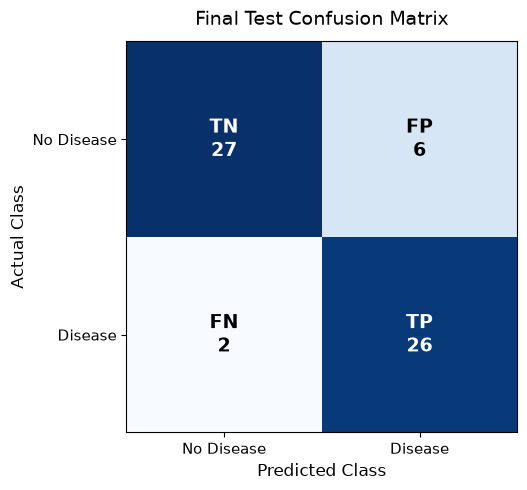

In [42]:
final_cm = confusion_matrix(
    y_test,
    final_test_pred
)

plot_confusion_matrix_readable(
    final_cm,
    "Final Test Confusion Matrix"
)


<h2 style="color:#0072B2;">17. Final Results & Project Conclusion</h2>

The final Logistic Regression Pipeline was trained using all **242 development observations** after model selection and feature-engineering decisions had been completed.

It was then evaluated once on the untouched **61-sample final test set**.

### Final Performance

- **Accuracy:** 0.869
- **Precision:** 0.812
- **Recall:** 0.929
- **F1-score:** 0.867
- **ROC-AUC:** 0.958

The final confusion matrix contained:

- **27 True Negatives**
- **6 False Positives**
- **2 False Negatives**
- **26 True Positives**

The model correctly identified 26 of the 28 positive observations in the final test set, resulting in a recall of **0.929**.

The final F1-score (**0.867**) was higher than the mean cross-validated F1-score observed during model development (**0.792**). This indicates that the held-out test split produced stronger performance than the average cross-validation fold, but the test result was not used to revise any modeling decision.

<span style="color:#009E73;"><b>Final conclusion:</b></span>  
Logistic Regression with the original feature representation is retained as the final supervised-learning workflow. It provided stronger average cross-validated performance than Random Forest, higher validation ROC-AUC, and strong performance on the untouched final test set.

### Limitations

This analysis has several important limitations:

- The dataset contains only **303 observations**, so performance estimates may vary across different samples.
- The Cleveland dataset contains fixed clinical observations rather than continuous time-series monitoring; therefore, this notebook implements the classification-analysis component of the monitoring project rather than real-time patient streaming.
- The binary target combines the original disease-severity values `1–4` into a single positive class, so severity is not modeled separately.
- The engineered interaction features tested in this project did not provide meaningful improvement, but other valid feature representations may behave differently.
- The model is an educational machine-learning classifier and is not intended for clinical diagnosis, treatment decisions, or emergency use.

<span style="color:#D55E00;"><b>Final evaluation discipline:</b></span>  
The final test set was evaluated only after model, preprocessing, and feature decisions were completed, and no further model-development decisions were made from its results.